# Complete EDA & Data Cleaning 
Datasets: Loan Eligibility | Adult Census Income | Hotel Booking
1. **Loan Dataset** (loan-train.csv)
2. **Adult Census Income Dataset** (adult.csv)
3. **Hotel Booking Dataset** (hotel_booking.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully')

Libraries imported successfully


---# DATASET 1: LOAN ELIGIBILITY DATASET---

## 1.1 Load Dataset & Initial Inspection

In [2]:
loan = pd.read_csv('loan-train.csv')  # ensure this file is in the same folder as the notebook
print('Shape:', loan.shape)
loan.head()

Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   object 
 1   Gender             1601 non-null   object 
 2   Married            1611 non-null   object 
 3   Dependents         1599 non-null   object 
 4   Education          1614 non-null   object 
 5   Self_Employed      1582 non-null   object 
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   object 
 12  Loan_Status        1614 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 164.1+ KB


In [4]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1592.000000,1600.000000,1564.00000
mean,8746.304833,3658.722999,218.846734,290.475000,0.63555
std,6249.885122,3291.745935,133.623293,81.899735,0.48143
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,324.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [5]:
loan.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,1614,1601,1611,1599,1614,1582,1614,1614
unique,1538,2,2,4,2,2,3,2
top,LP006706,Male,Yes,0,Graduate,No,Urban,Y
freq,3,980,925,619,952,999,549,915


## 1.2 Missing Values Check

In [6]:
missing_loan = loan.isnull().sum()
missing_percent = (loan.isnull().sum() / len(loan)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_loan, 'Missing_Percent': missing_percent})
missing_df[missing_df['Missing_Count'] > 0]

,Missing_Count,Missing_Percent
Gender,13,0.805452
Married,3,0.185874
Dependents,15,0.929368
Self_Employed,32,1.982652
LoanAmount,22,1.363073
Loan_Amount_Term,14,0.867410
Credit_History,50,3.097893


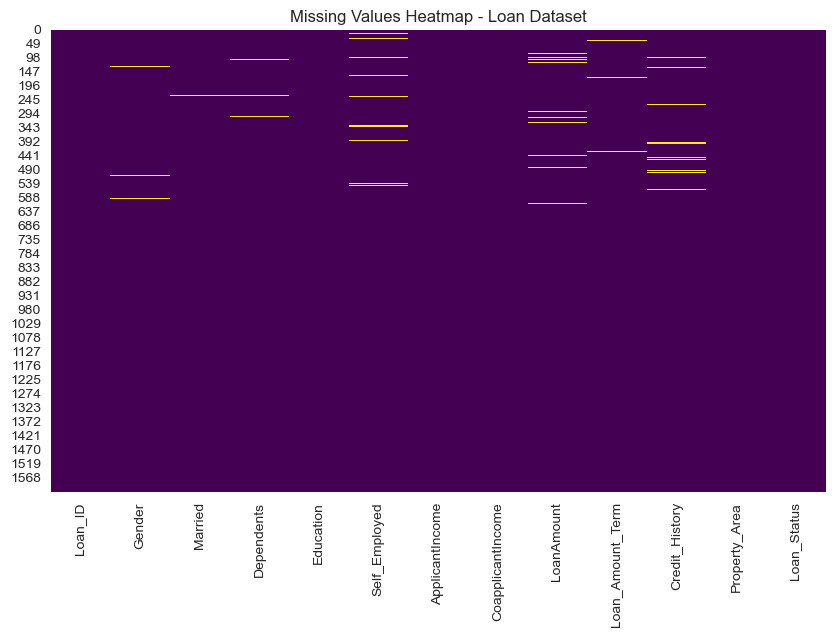

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(loan.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Loan Dataset')
plt.show()

## 1.3 Column-wise Analysis (Univariate)

### Loan_ID — Unique identifier, drop kar denge (analysis ke liye useless)

In [8]:
print('Unique Loan_IDs:', loan['Loan_ID'].nunique(), 'out of', len(loan))

Unique Loan_IDs: 1538 out of 1614


### Gender

Gender
Male      980
Female    621
Name: count, dtype: int64


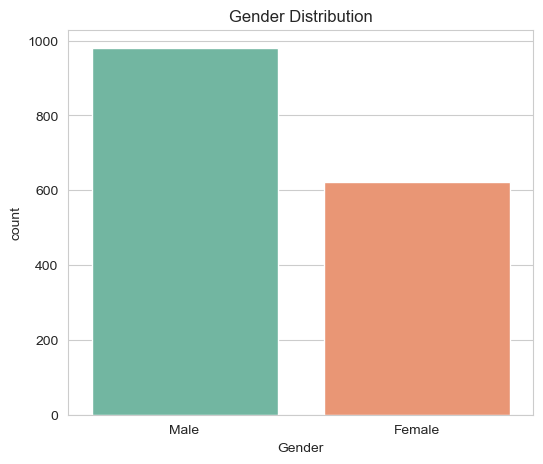

In [9]:
print(loan['Gender'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=loan, hue='Gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.show()

### Married

Married
Yes    925
No     686
Name: count, dtype: int64


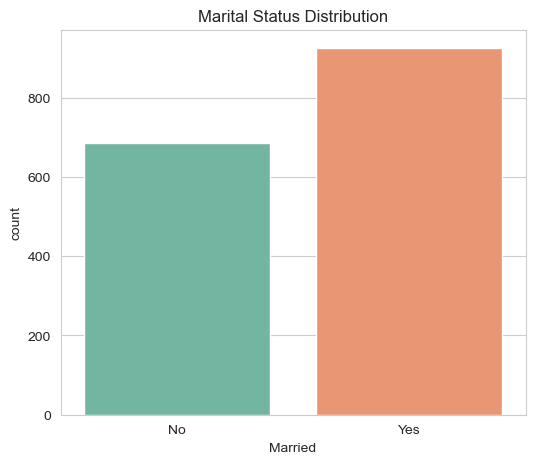

In [10]:
print(loan['Married'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Married', data=loan, hue='Married', palette='Set2', legend=False)
plt.title('Marital Status Distribution')
plt.show()

### Dependents

Dependents
0     619
1     341
2     336
3+    303
Name: count, dtype: int64


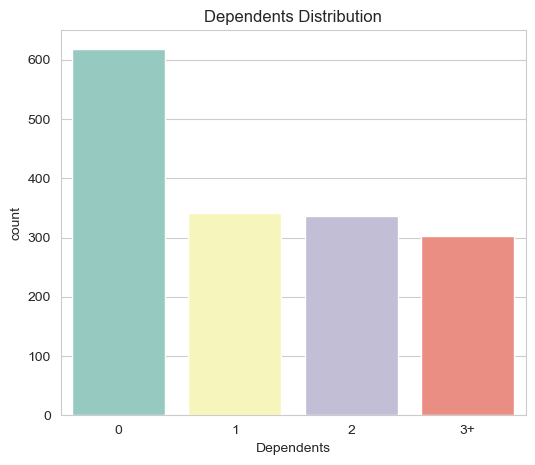

In [11]:
print(loan['Dependents'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Dependents', data=loan, hue='Dependents', palette='Set3', legend=False)
plt.title('Dependents Distribution')
plt.show()

### Education

Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


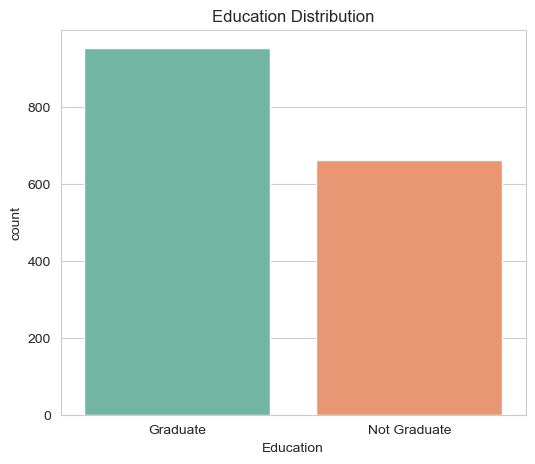

In [12]:
print(loan['Education'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Education', data=loan, hue='Education', palette='Set2', legend=False)
plt.title('Education Distribution')
plt.show()

### Self_Employed

Self_Employed
No     999
Yes    583
Name: count, dtype: int64


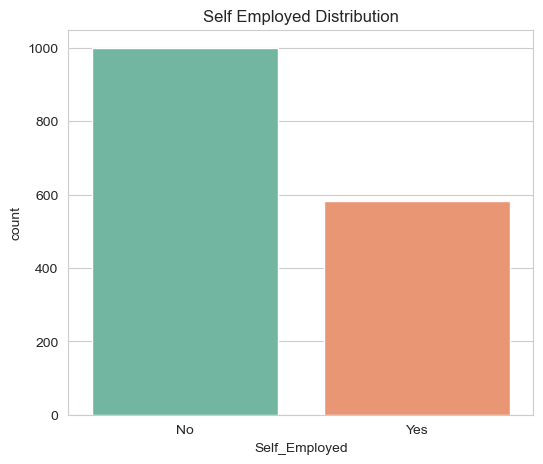

In [13]:
print(loan['Self_Employed'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Self_Employed', data=loan, hue='Self_Employed', palette='Set2', legend=False)
plt.title('Self Employed Distribution')
plt.show()

### ApplicantIncome

count     1614.000000
mean      8746.304833
std       6249.885122
min        150.000000
25%       3675.250000
50%       7045.000000
75%      13251.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64


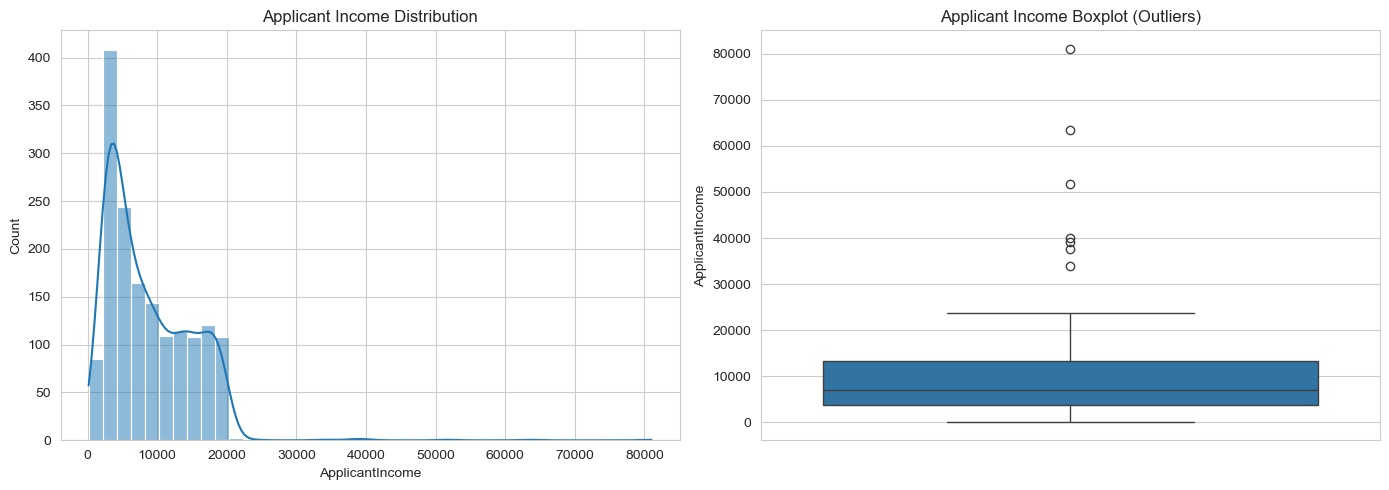

In [14]:
print(loan['ApplicantIncome'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(loan['ApplicantIncome'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Applicant Income Distribution')
sns.boxplot(y=loan['ApplicantIncome'], ax=axes[1])
axes[1].set_title('Applicant Income Boxplot (Outliers)')
plt.tight_layout()
plt.show()

### CoapplicantIncome

count     1614.000000
mean      3658.722999
std       3291.745935
min          0.000000
25%        986.250000
50%       2941.500000
75%       5893.000000
max      41667.000000
Name: CoapplicantIncome, dtype: float64


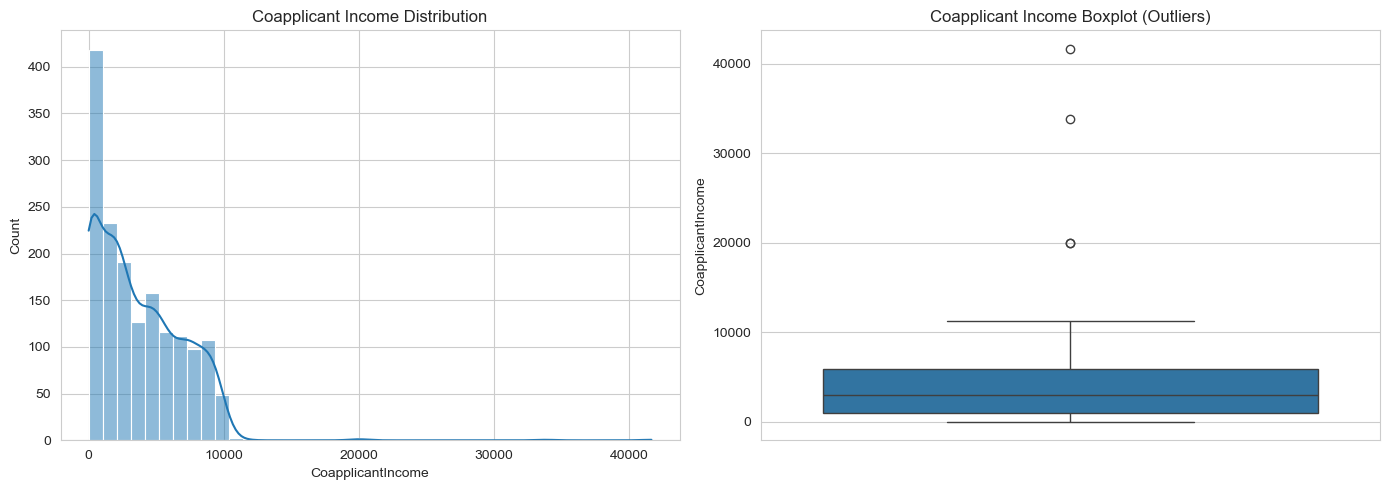

In [15]:
print(loan['CoapplicantIncome'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(loan['CoapplicantIncome'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Coapplicant Income Distribution')
sns.boxplot(y=loan['CoapplicantIncome'], ax=axes[1])
axes[1].set_title('Coapplicant Income Boxplot (Outliers)')
plt.tight_layout()
plt.show()

### LoanAmount

count    1592.000000
mean      218.846734
std       133.623293
min         9.000000
25%       112.000000
50%       180.000000
75%       324.000000
max       700.000000
Name: LoanAmount, dtype: float64


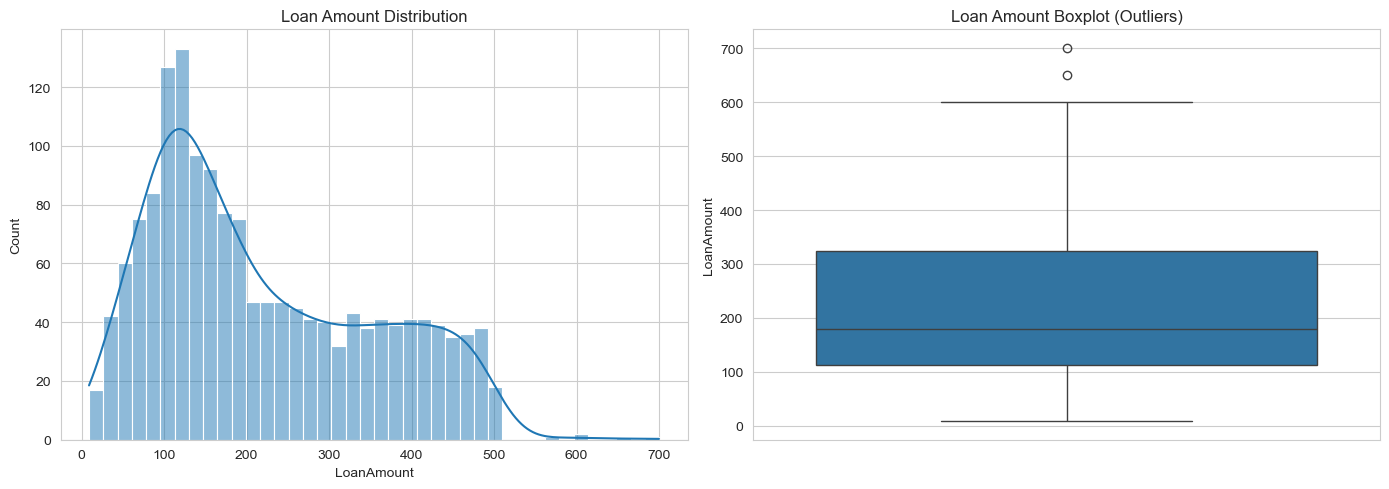

In [16]:
print(loan['LoanAmount'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(loan['LoanAmount'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('Loan Amount Distribution')
sns.boxplot(y=loan['LoanAmount'], ax=axes[1])
axes[1].set_title('Loan Amount Boxplot (Outliers)')
plt.tight_layout()
plt.show()

### Loan_Amount_Term

Loan_Amount_Term
360.0    845
180.0    384
240.0    331
480.0     15
300.0     13
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64


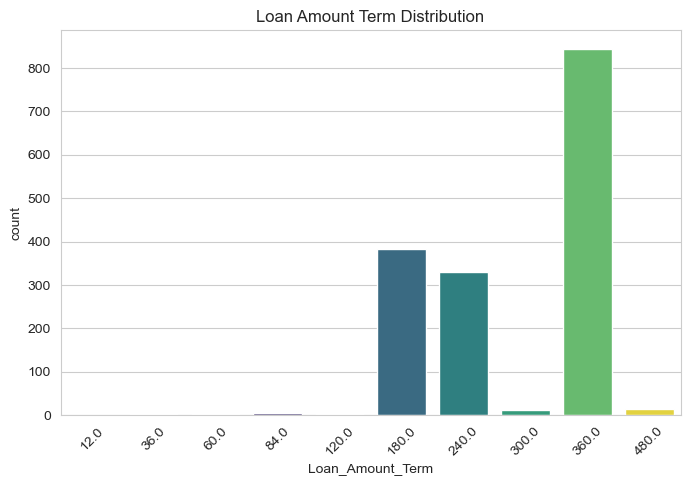

In [17]:
print(loan['Loan_Amount_Term'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='Loan_Amount_Term', data=loan, hue='Loan_Amount_Term', palette='viridis', legend=False)
plt.title('Loan Amount Term Distribution')
plt.xticks(rotation=45)
plt.show()

### Credit_History

Credit_History
1.0    994
0.0    570
Name: count, dtype: int64


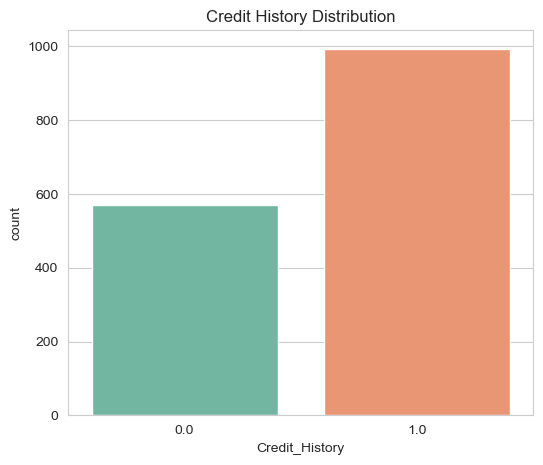

In [18]:
print(loan['Credit_History'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Credit_History', data=loan, hue='Credit_History', palette='Set2', legend=False)
plt.title('Credit History Distribution')
plt.show()

### Property_Area

Property_Area
Urban        549
Semiurban    545
Rural        520
Name: count, dtype: int64


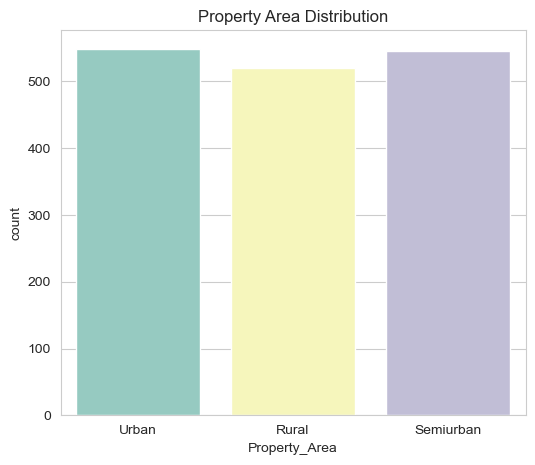

In [19]:
print(loan['Property_Area'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Property_Area', data=loan, hue='Property_Area', palette='Set3', legend=False)
plt.title('Property Area Distribution')
plt.show()

### Loan_Status (Target Variable)

Loan_Status
Y    915
N    699
Name: count, dtype: int64


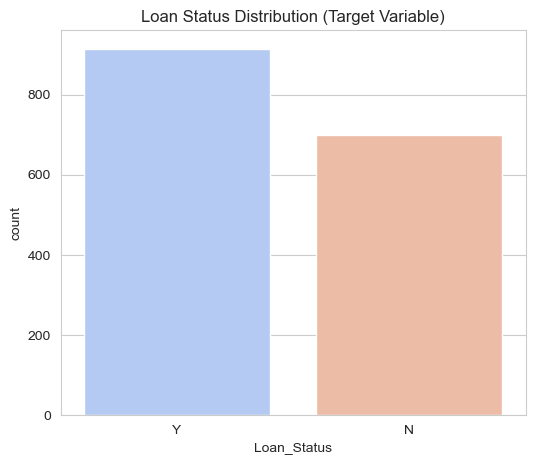

In [20]:
print(loan['Loan_Status'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='Loan_Status', data=loan, hue='Loan_Status', palette='coolwarm', legend=False)
plt.title('Loan Status Distribution (Target Variable)')
plt.show()

## 1.4 Bivariate Analysis (Relation with Target)

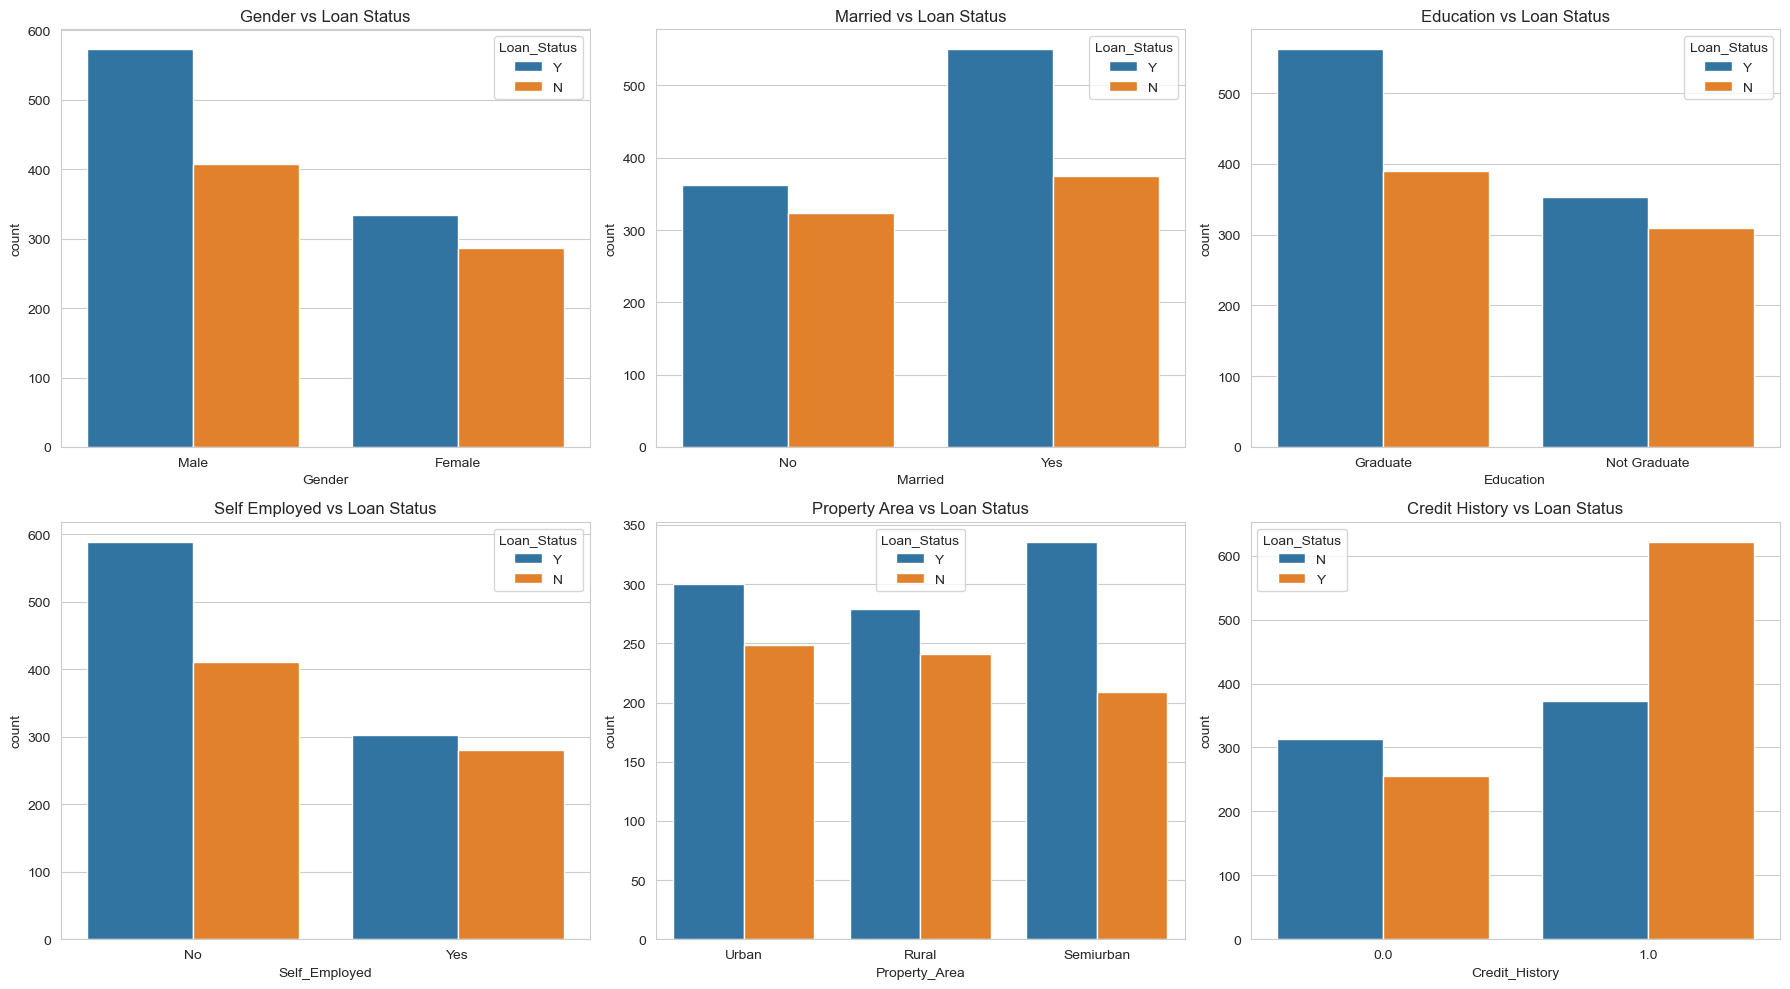

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

sns.countplot(x='Gender', hue='Loan_Status', data=loan, ax=axes[0,0])
axes[0,0].set_title('Gender vs Loan Status')

sns.countplot(x='Married', hue='Loan_Status', data=loan, ax=axes[0,1])
axes[0,1].set_title('Married vs Loan Status')

sns.countplot(x='Education', hue='Loan_Status', data=loan, ax=axes[0,2])
axes[0,2].set_title('Education vs Loan Status')

sns.countplot(x='Self_Employed', hue='Loan_Status', data=loan, ax=axes[1,0])
axes[1,0].set_title('Self Employed vs Loan Status')

sns.countplot(x='Property_Area', hue='Loan_Status', data=loan, ax=axes[1,1])
axes[1,1].set_title('Property Area vs Loan Status')

sns.countplot(x='Credit_History', hue='Loan_Status', data=loan, ax=axes[1,2])
axes[1,2].set_title('Credit History vs Loan Status')

plt.tight_layout()
plt.show()

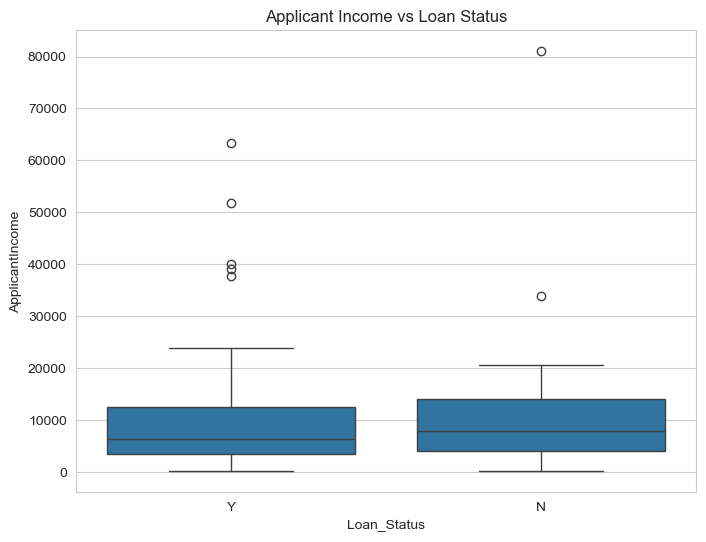

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=loan)
plt.title('Applicant Income vs Loan Status')
plt.show()

## 1.5 Correlation Analysis

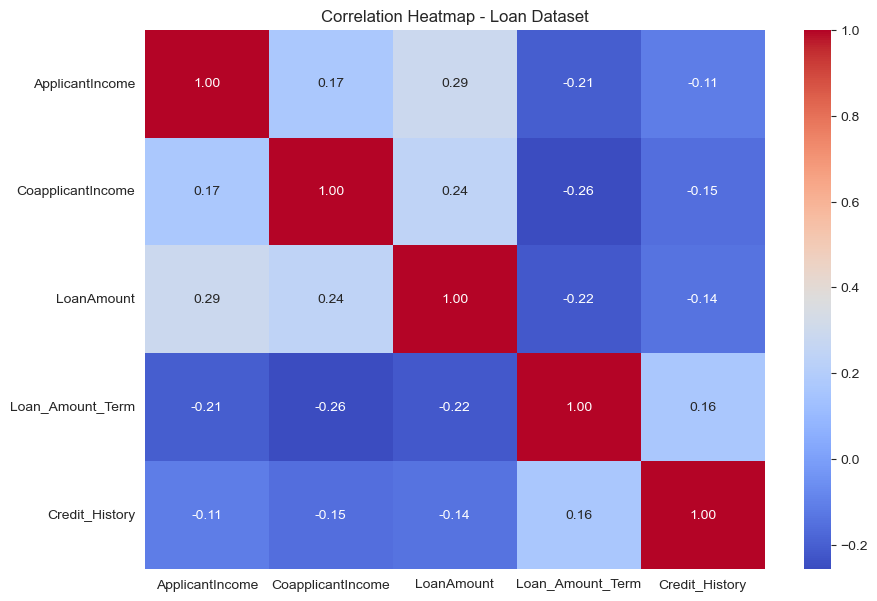

In [23]:
plt.figure(figsize=(10,7))
numeric_loan = loan.select_dtypes(include=[np.number])
sns.heatmap(numeric_loan.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Loan Dataset')
plt.show()

## 1.6 Data Cleaning

In [24]:
loan_clean = loan.copy()

# Drop Loan_ID - not useful for analysis
loan_clean.drop('Loan_ID', axis=1, inplace=True)

# Fill categorical missing values with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    loan_clean[col] = loan_clean[col].fillna(loan_clean[col].mode()[0])

# Fill numeric missing values with median
loan_clean['LoanAmount'] = loan_clean['LoanAmount'].fillna(loan_clean['LoanAmount'].median())
loan_clean['Loan_Amount_Term'] = loan_clean['Loan_Amount_Term'].fillna(loan_clean['Loan_Amount_Term'].mode()[0])
loan_clean['Credit_History'] = loan_clean['Credit_History'].fillna(loan_clean['Credit_History'].mode()[0])

print('Missing values after cleaning:')
print(loan_clean.isnull().sum())

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [25]:
# Handle Outliers using IQR method for ApplicantIncome and LoanAmount
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

print('Before removing outliers:', loan_clean.shape)
loan_clean = remove_outliers_iqr(loan_clean, 'ApplicantIncome')
loan_clean = remove_outliers_iqr(loan_clean, 'LoanAmount')
print('After removing outliers:', loan_clean.shape)

Before removing outliers: (1614, 12)
After removing outliers: (1606, 12)


In [26]:
# Standardize Dependents column (3+ -> 3)
loan_clean['Dependents'] = loan_clean['Dependents'].replace('3+', '3').astype(int)
print(loan_clean['Dependents'].value_counts())

Dependents
0    631
1    339
2    336
3    300
Name: count, dtype: int64


In [27]:
# Save cleaned loan dataset
loan_clean.to_csv('cleaned_loan.csv', index=False)
loan_clean.head()
print('Cleaned Loan dataset saved as cleaned_loan.csv')

Cleaned Loan dataset saved as cleaned_loan.csv


---# DATASET 2: ADULT CENSUS INCOME DATASET---

## 2.1 Load Dataset & Initial Inspection

In [28]:
adult = pd.read_csv('adult.csv')
print('Shape:', adult.shape)
adult.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [29]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [30]:
adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [31]:
adult.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


## 2.2 Missing Values CheckIs dataset mein missing values `'?'` ke roop mein represented hain, NaN nahi.

In [32]:
print('Standard NaN check:')
print(adult.isnull().sum().sum())

print('\nColumns with "?" placeholder values:')
for col in adult.select_dtypes(include='object').columns:
    count = (adult[col] == '?').sum()
    if count > 0:
        print(f'{col}: {count} ({round(count/len(adult)*100,2)}%)')

Standard NaN check:
0

Columns with "?" placeholder values:
workclass: 2799 (5.73%)
occupation: 2809 (5.75%)
native-country: 857 (1.75%)


## 2.3 Column-wise Analysis (Univariate)

### age

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


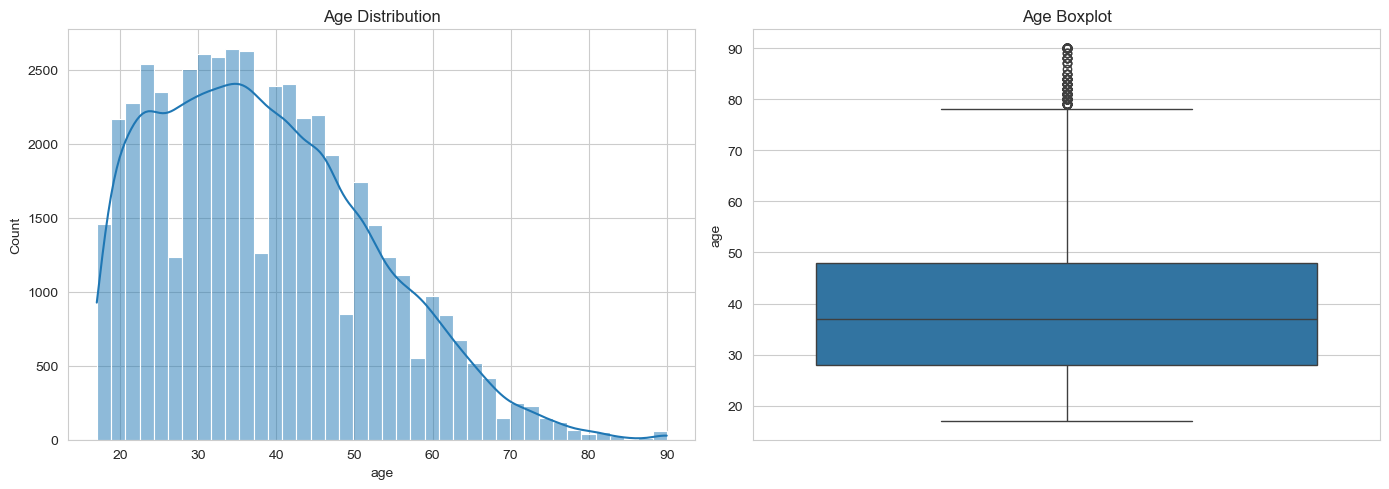

In [33]:
print(adult['age'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(adult['age'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.boxplot(y=adult['age'], ax=axes[1])
axes[1].set_title('Age Boxplot')
plt.tight_layout()
plt.show()

### workclass

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


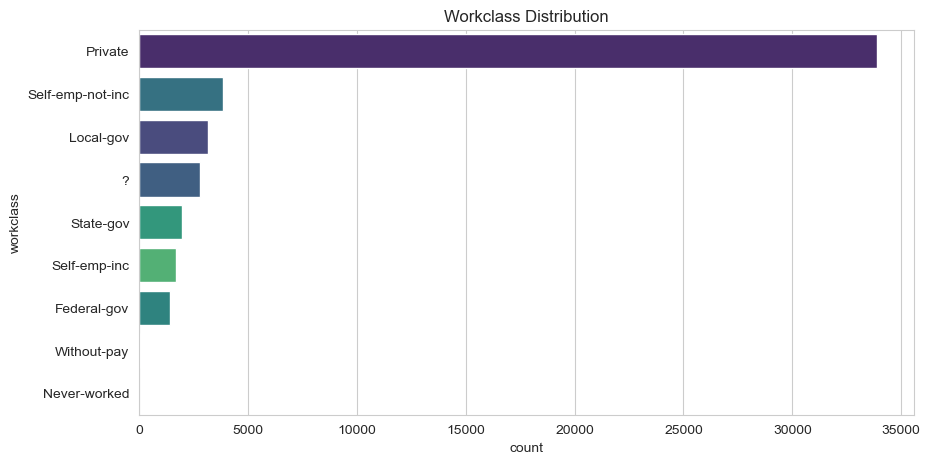

In [34]:
print(adult['workclass'].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(y='workclass', data=adult, order=adult['workclass'].value_counts().index, hue='workclass', palette='viridis', legend=False)
plt.title('Workclass Distribution')
plt.show()

### fnlwgt (Final Weight - census sampling weight)

count    4.884200e+04
mean     1.896641e+05
std      1.056040e+05
min      1.228500e+04
25%      1.175505e+05
50%      1.781445e+05
75%      2.376420e+05
max      1.490400e+06
Name: fnlwgt, dtype: float64


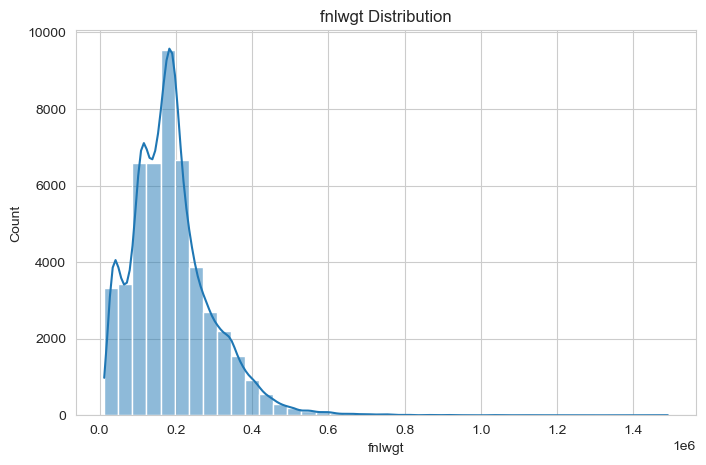

In [35]:
print(adult['fnlwgt'].describe())
plt.figure(figsize=(8,5))
sns.histplot(adult['fnlwgt'], bins=40, kde=True)
plt.title('fnlwgt Distribution')
plt.show()

### education

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


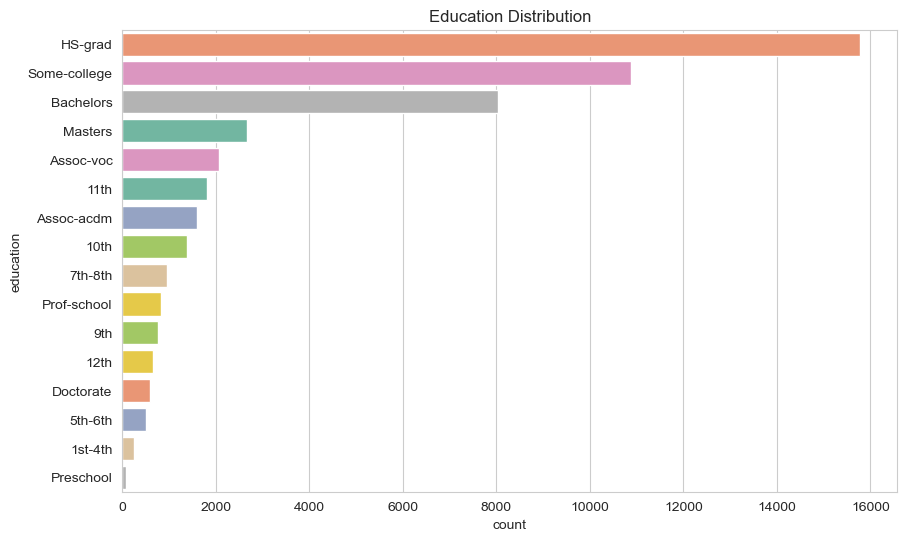

In [36]:
print(adult['education'].value_counts())
plt.figure(figsize=(10,6))
sns.countplot(y='education', data=adult, order=adult['education'].value_counts().index, hue='education', palette='Set2', legend=False)
plt.title('Education Distribution')
plt.show()

### educational-num

count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: educational-num, dtype: float64


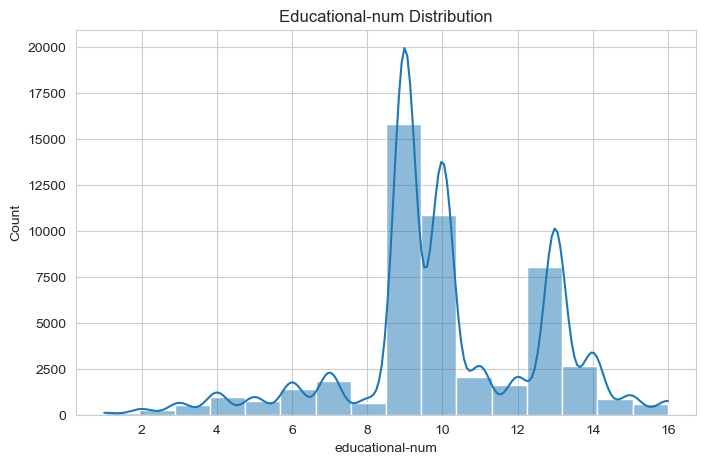

In [37]:
print(adult['educational-num'].describe())
plt.figure(figsize=(8,5))
sns.histplot(adult['educational-num'], bins=16, kde=True)
plt.title('Educational-num Distribution')
plt.show()

### marital-status

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


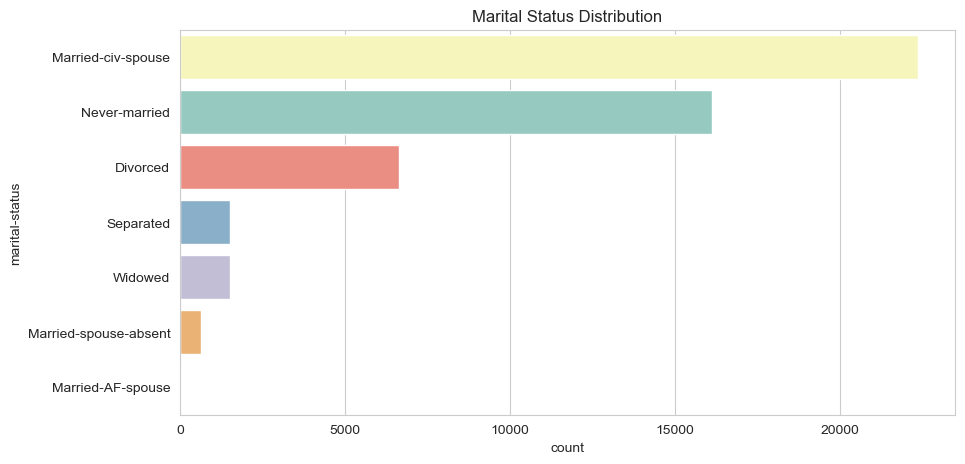

In [38]:
print(adult['marital-status'].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(y='marital-status', data=adult, order=adult['marital-status'].value_counts().index, hue='marital-status', palette='Set3', legend=False)
plt.title('Marital Status Distribution')
plt.show()

### occupation

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
?                    2809
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


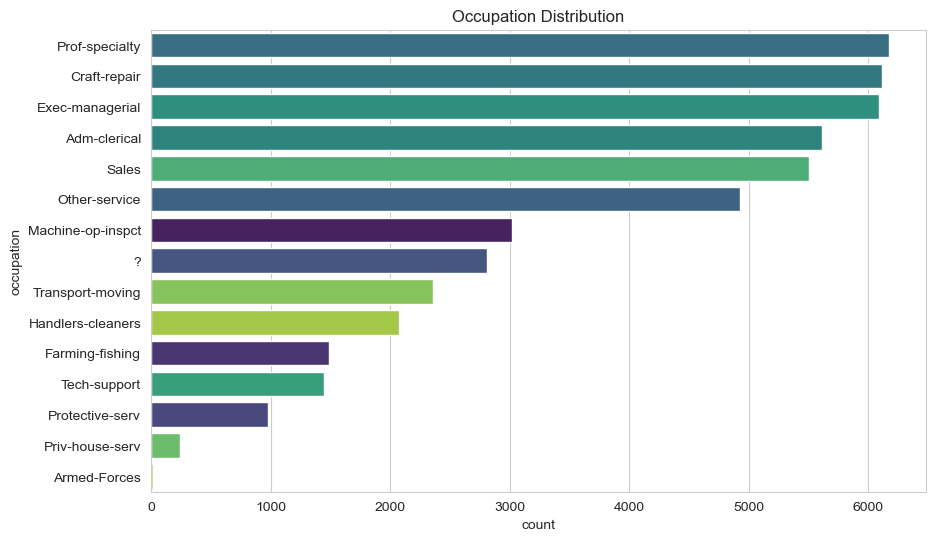

In [39]:
print(adult['occupation'].value_counts())
plt.figure(figsize=(10,6))
sns.countplot(y='occupation', data=adult, order=adult['occupation'].value_counts().index, hue='occupation', palette='viridis', legend=False)
plt.title('Occupation Distribution')
plt.show()

### relationship

relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64


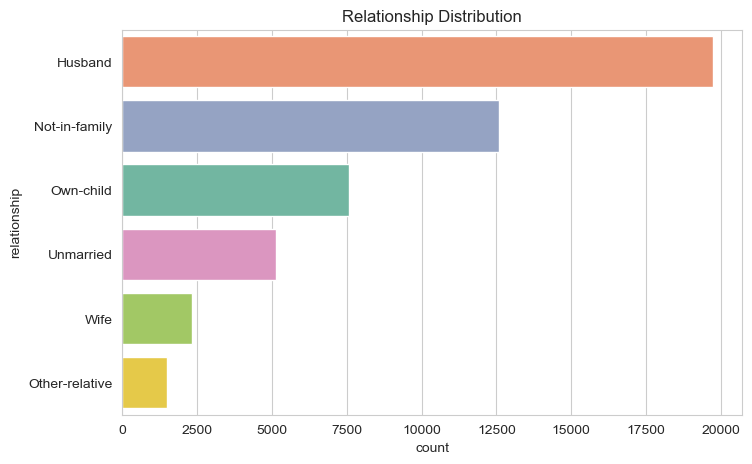

In [40]:
print(adult['relationship'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(y='relationship', data=adult, order=adult['relationship'].value_counts().index, hue='relationship', palette='Set2', legend=False)
plt.title('Relationship Distribution')
plt.show()

### race

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64


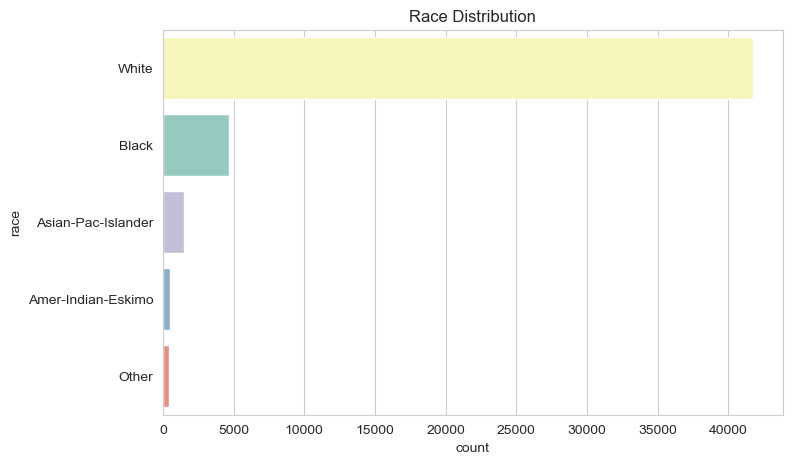

In [41]:
print(adult['race'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(y='race', data=adult, order=adult['race'].value_counts().index, hue='race', palette='Set3', legend=False)
plt.title('Race Distribution')
plt.show()

### gender

gender
Male      32650
Female    16192
Name: count, dtype: int64


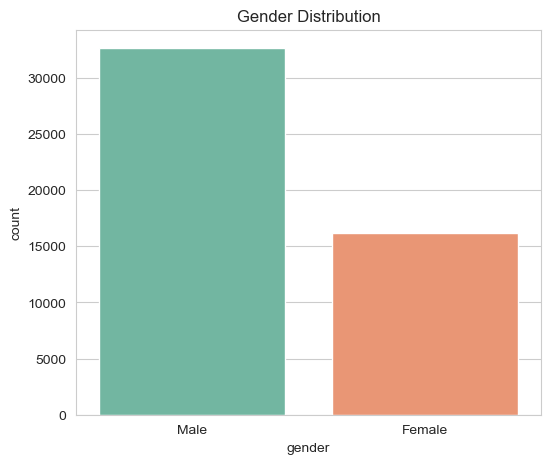

In [42]:
print(adult['gender'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=adult, hue='gender', palette='Set2', legend=False)
plt.title('Gender Distribution')
plt.show()

### capital-gain

count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values: 44807 out of 48842


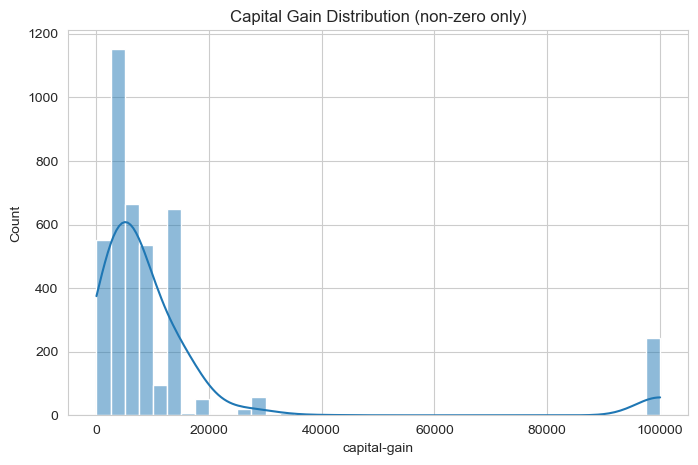

In [43]:
print(adult['capital-gain'].describe())
print('\nZero values:', (adult['capital-gain']==0).sum(), 'out of', len(adult))
plt.figure(figsize=(8,5))
sns.histplot(adult[adult['capital-gain']>0]['capital-gain'], bins=40, kde=True)
plt.title('Capital Gain Distribution (non-zero only)')
plt.show()

### capital-loss

count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values: 46560 out of 48842


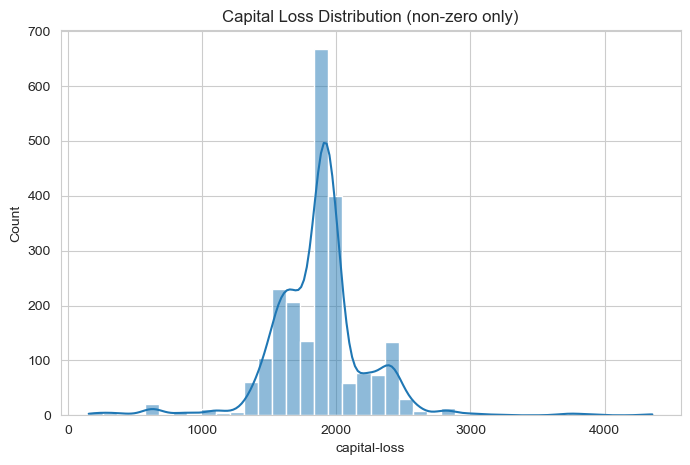

In [44]:
print(adult['capital-loss'].describe())
print('\nZero values:', (adult['capital-loss']==0).sum(), 'out of', len(adult))
plt.figure(figsize=(8,5))
sns.histplot(adult[adult['capital-loss']>0]['capital-loss'], bins=40, kde=True)
plt.title('Capital Loss Distribution (non-zero only)')
plt.show()

### hours-per-week

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


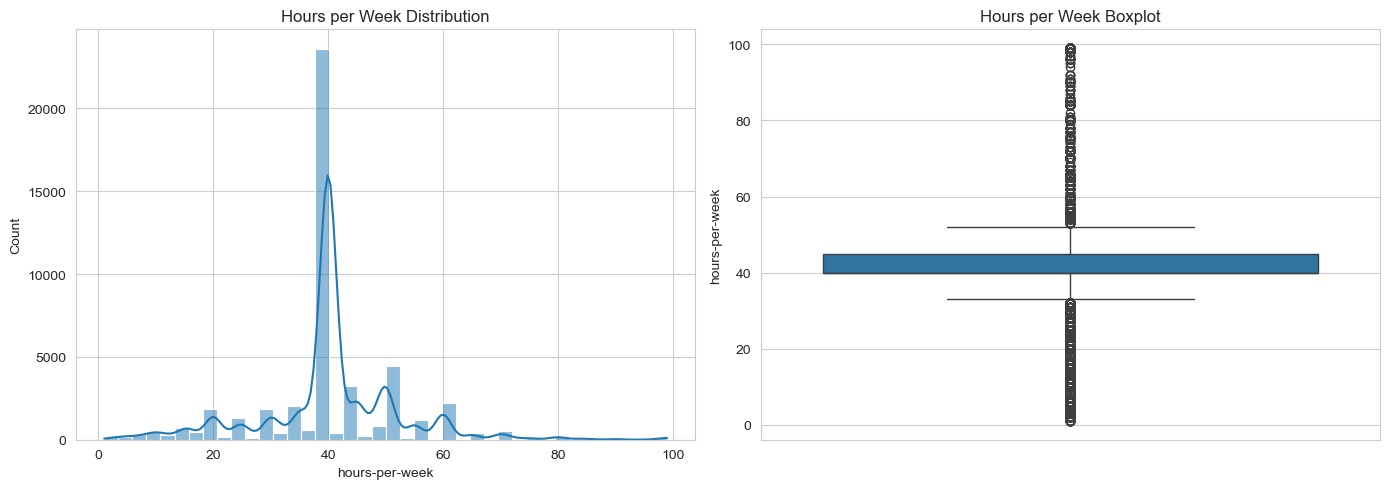

In [45]:
print(adult['hours-per-week'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(adult['hours-per-week'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Hours per Week Distribution')
sns.boxplot(y=adult['hours-per-week'], ax=axes[1])
axes[1].set_title('Hours per Week Boxplot')
plt.tight_layout()
plt.show()

### native-country

native-country
United-States    43832
Mexico             951
?                  857
Philippines        295
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64


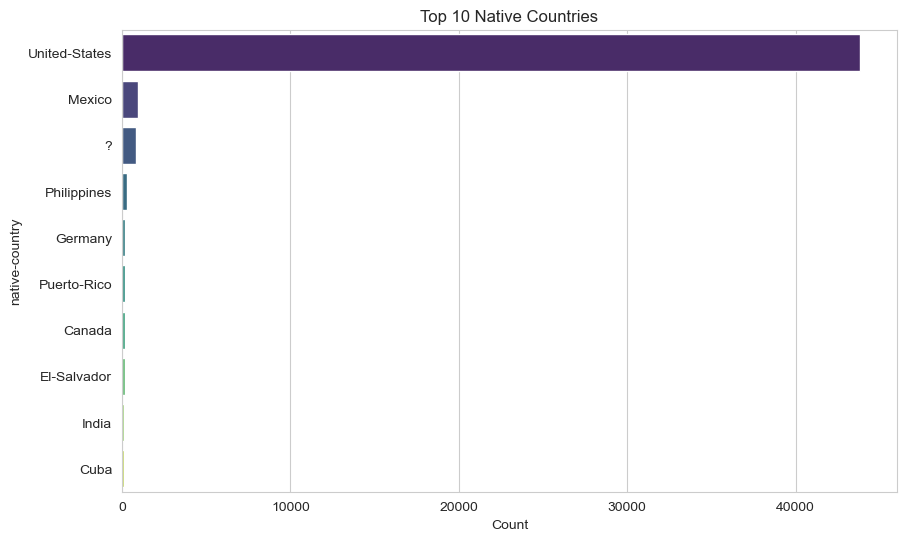

In [46]:
print(adult['native-country'].value_counts().head(10))
plt.figure(figsize=(10,6))
top10_country = adult['native-country'].value_counts().head(10)
sns.barplot(x=top10_country.values, y=top10_country.index, hue=top10_country.index, palette='viridis', legend=False)
plt.title('Top 10 Native Countries')
plt.xlabel('Count')
plt.show()

### income (Target Variable)

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


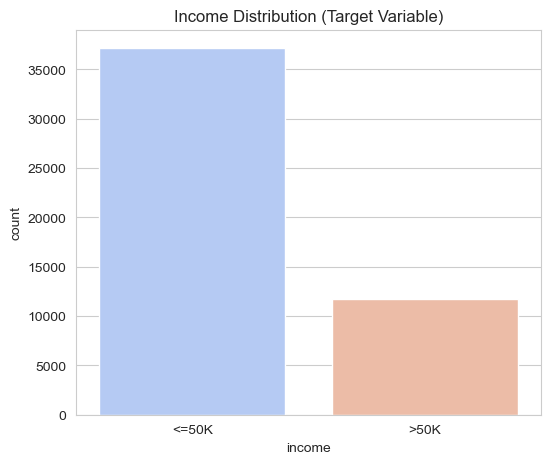

In [47]:
print(adult['income'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='income', data=adult, hue='income', palette='coolwarm', legend=False)
plt.title('Income Distribution (Target Variable)')
plt.show()

## 2.4 Bivariate Analysis (Relation with Income)

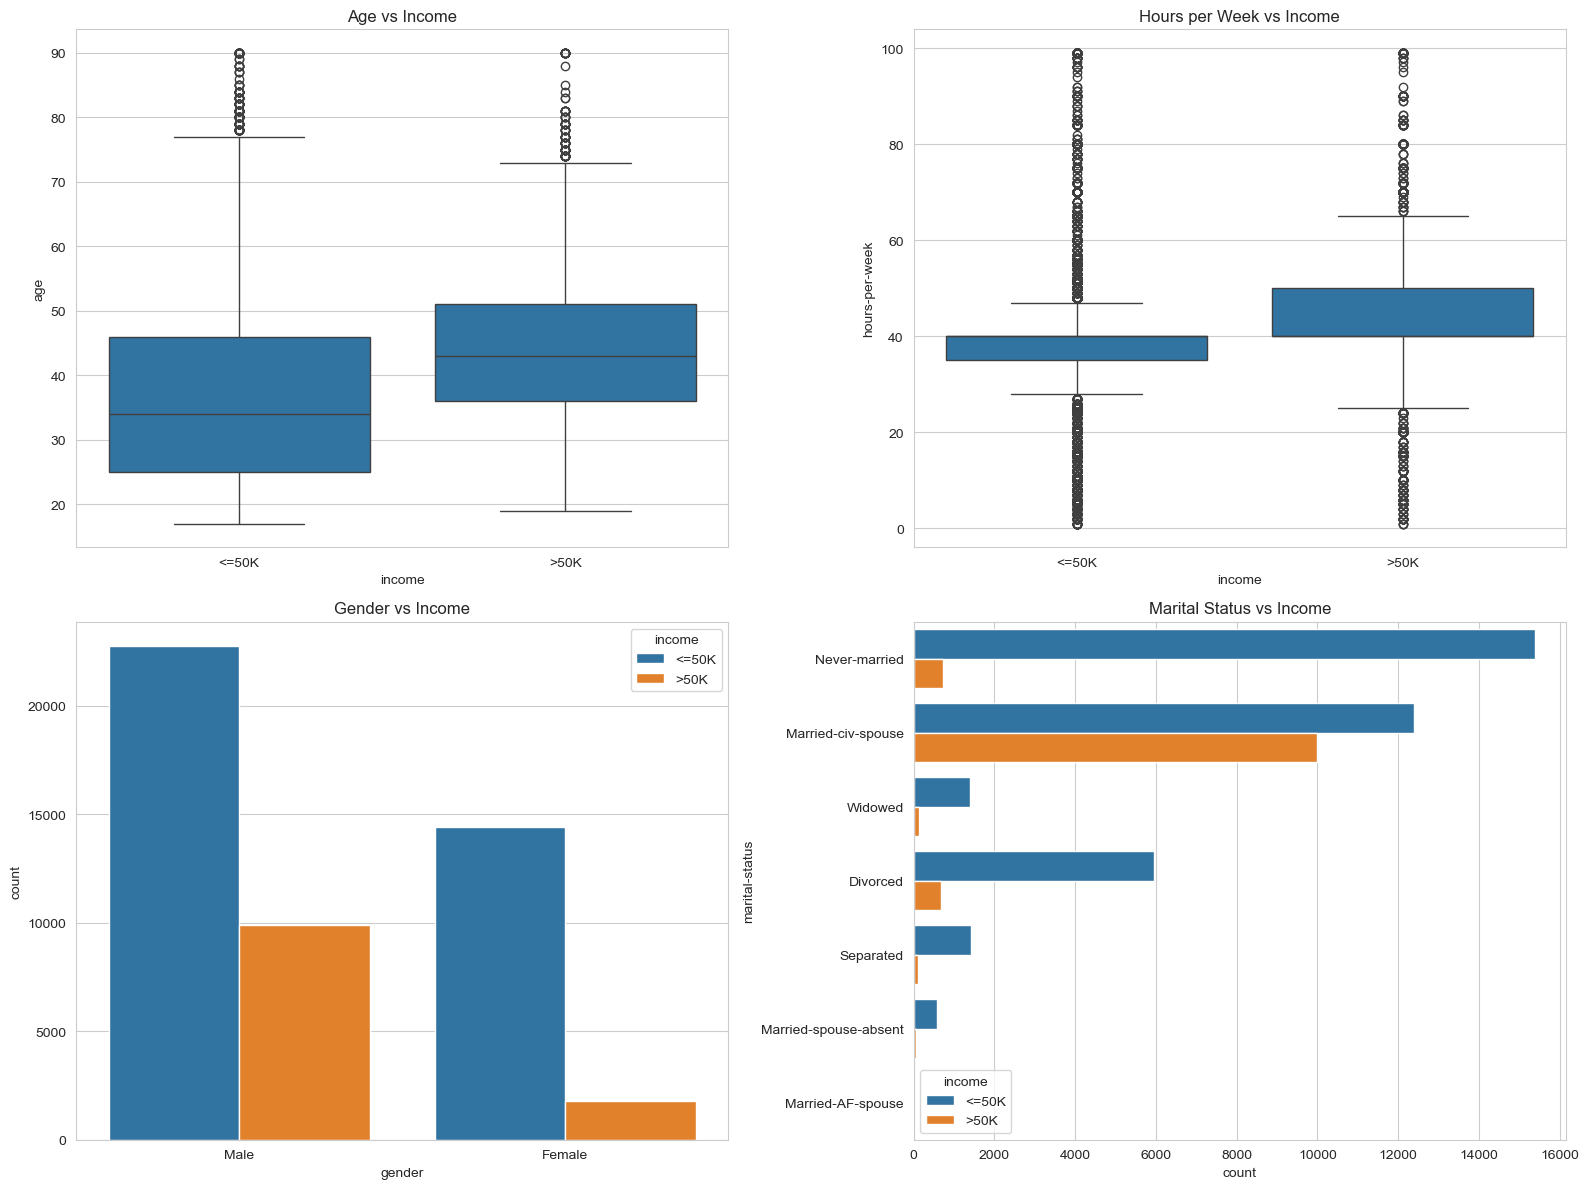

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

sns.boxplot(x='income', y='age', data=adult, ax=axes[0,0])
axes[0,0].set_title('Age vs Income')

sns.boxplot(x='income', y='hours-per-week', data=adult, ax=axes[0,1])
axes[0,1].set_title('Hours per Week vs Income')

sns.countplot(x='gender', hue='income', data=adult, ax=axes[1,0])
axes[1,0].set_title('Gender vs Income')

sns.countplot(y='marital-status', hue='income', data=adult, ax=axes[1,1])
axes[1,1].set_title('Marital Status vs Income')

plt.tight_layout()
plt.show()

## 2.5 Correlation Analysis

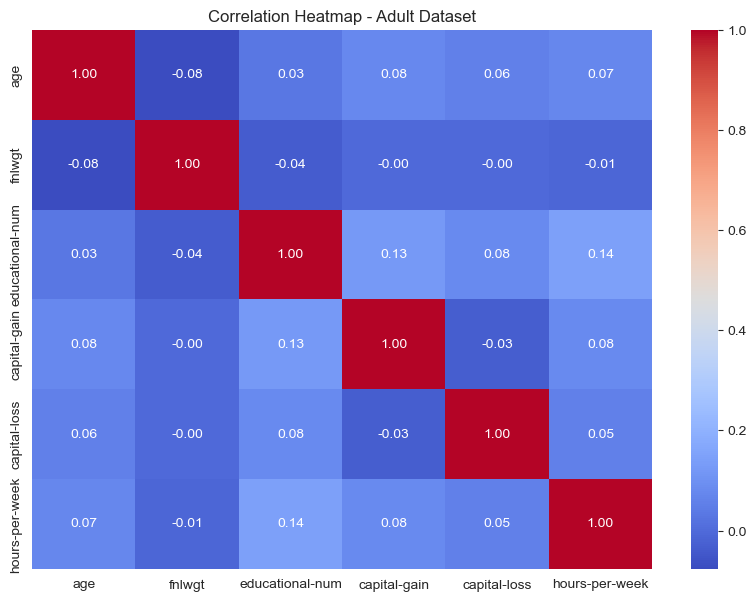

In [49]:
plt.figure(figsize=(10,7))
numeric_adult = adult.select_dtypes(include=[np.number])
sns.heatmap(numeric_adult.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Adult Dataset')
plt.show()

## 2.6 Data Cleaning

In [50]:
adult_clean = adult.copy()

# Replace '?' with NaN
adult_clean.replace('?', np.nan, inplace=True)

print('Missing values after replacing "?":')
print(adult_clean.isnull().sum()[adult_clean.isnull().sum() > 0])

Missing values after replacing "?":
workclass         2799
occupation        2809
native-country     857
dtype: int64


In [51]:
# Fill missing categorical values with mode
for col in ['workclass', 'occupation', 'native-country']:
    adult_clean[col] = adult_clean[col].fillna(adult_clean[col].mode()[0])

print('Missing values after cleaning:', adult_clean.isnull().sum().sum())

Missing values after cleaning: 0


In [52]:
# Remove duplicate rows
print('Duplicates before:', adult_clean.duplicated().sum())
adult_clean.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', adult_clean.shape)

Duplicates before: 53
Shape after removing duplicates: (48789, 15)


In [53]:
# Handle outliers in age and hours-per-week using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

print('Before removing outliers:', adult_clean.shape)
adult_clean = remove_outliers_iqr(adult_clean, 'age')
print('After removing age outliers:', adult_clean.shape)

Before removing outliers: (48789, 15)
After removing age outliers: (48574, 15)


In [54]:
# Save cleaned adult dataset
adult_clean.to_csv('cleaned_adult.csv', index=False)
adult_clean.head()
print('Cleaned Adult dataset saved as cleaned_adult.csv')

Cleaned Adult dataset saved as cleaned_adult.csv


---# DATASET 3: HOTEL BOOKING DATASET---

## 3.1 Load Dataset & Initial Inspection

In [55]:
hotel = pd.read_csv('hotel_booking.csv')
print('Shape:', hotel.shape)
hotel.head()

Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [56]:
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [57]:
hotel.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 3.2 Missing Values Check

In [58]:
missing_hotel = hotel.isnull().sum()
missing_percent_hotel = (hotel.isnull().sum() / len(hotel)) * 100
missing_hotel_df = pd.DataFrame({'Missing_Count': missing_hotel, 'Missing_Percent': missing_percent_hotel})
missing_hotel_df[missing_hotel_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

,Missing_Count,Missing_Percent
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


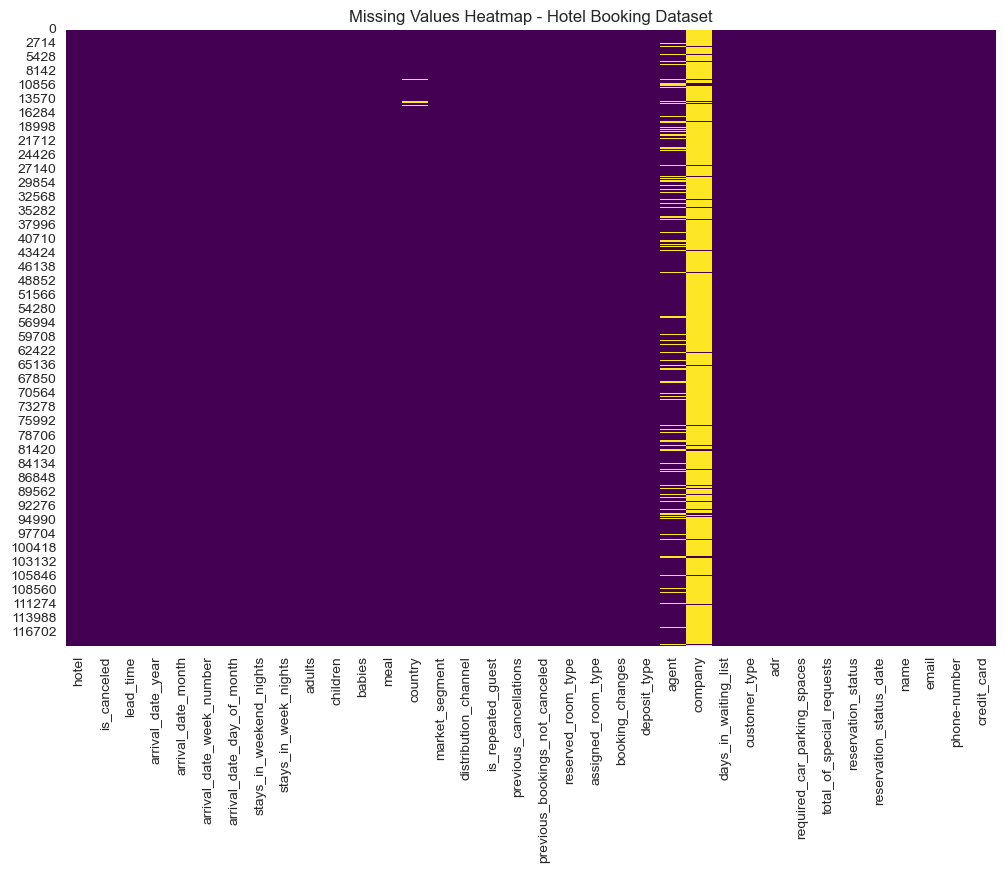

In [59]:
plt.figure(figsize=(12,8))
sns.heatmap(hotel.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Hotel Booking Dataset')
plt.show()

## 3.3 Column-wise Analysis (Univariate)

### hotel (City Hotel / Resort Hotel)

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


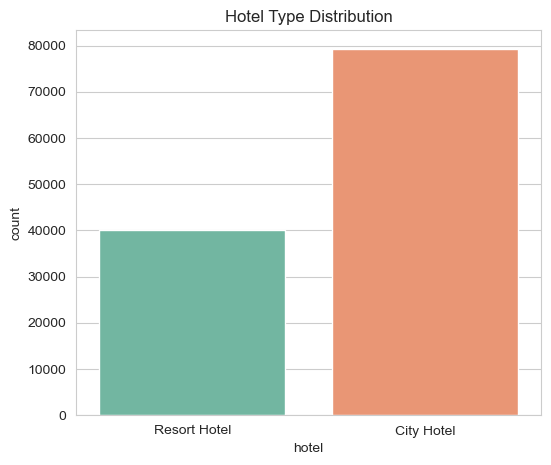

In [60]:
print(hotel['hotel'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='hotel', data=hotel, hue='hotel', palette='Set2', legend=False)
plt.title('Hotel Type Distribution')
plt.show()

### is_canceled (Target-like variable)

is_canceled
0    75166
1    44224
Name: count, dtype: int64


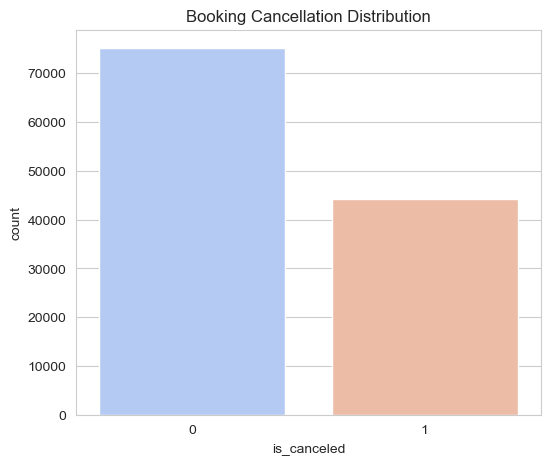

In [61]:
print(hotel['is_canceled'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='is_canceled', data=hotel, hue='is_canceled', palette='coolwarm', legend=False)
plt.title('Booking Cancellation Distribution')
plt.show()

### lead_time

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


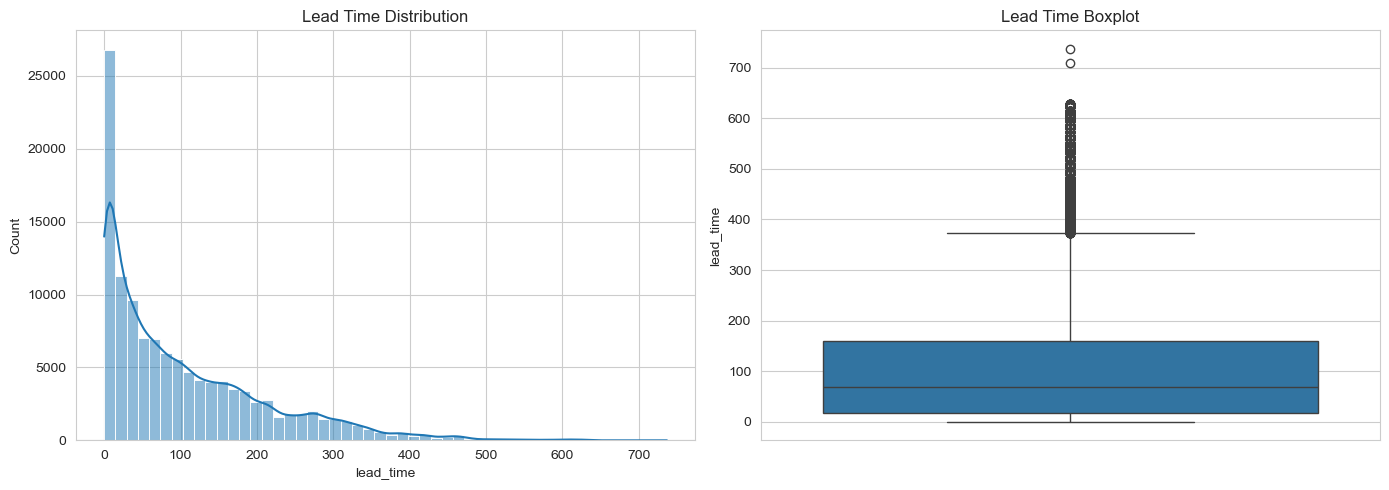

In [62]:
print(hotel['lead_time'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(hotel['lead_time'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Lead Time Distribution')
sns.boxplot(y=hotel['lead_time'], ax=axes[1])
axes[1].set_title('Lead Time Boxplot')
plt.tight_layout()
plt.show()

### arrival_date_year

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64


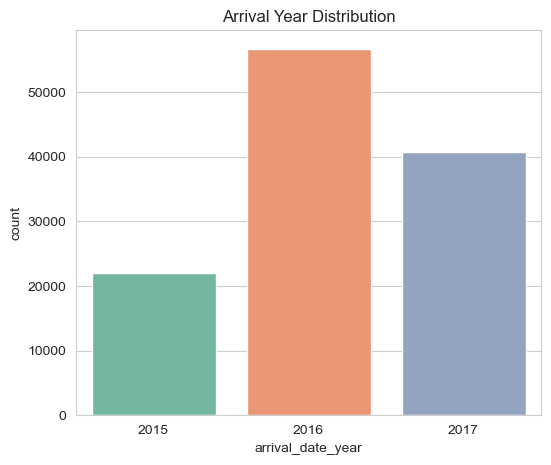

In [63]:
print(hotel['arrival_date_year'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='arrival_date_year', data=hotel, hue='arrival_date_year', palette='Set2', legend=False)
plt.title('Arrival Year Distribution')
plt.show()

### arrival_date_month

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64


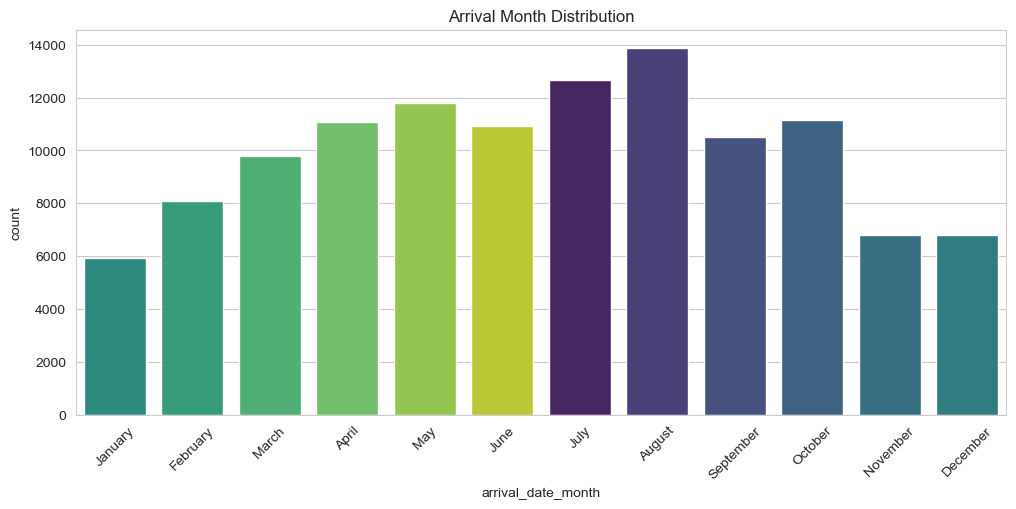

In [64]:
print(hotel['arrival_date_month'].value_counts())
plt.figure(figsize=(12,5))
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
sns.countplot(x='arrival_date_month', data=hotel, order=month_order, hue='arrival_date_month', palette='viridis', legend=False)
plt.title('Arrival Month Distribution')
plt.xticks(rotation=45)
plt.show()

### arrival_date_week_number

count    119390.000000
mean         27.165173
std          13.605138
min           1.000000
25%          16.000000
50%          28.000000
75%          38.000000
max          53.000000
Name: arrival_date_week_number, dtype: float64


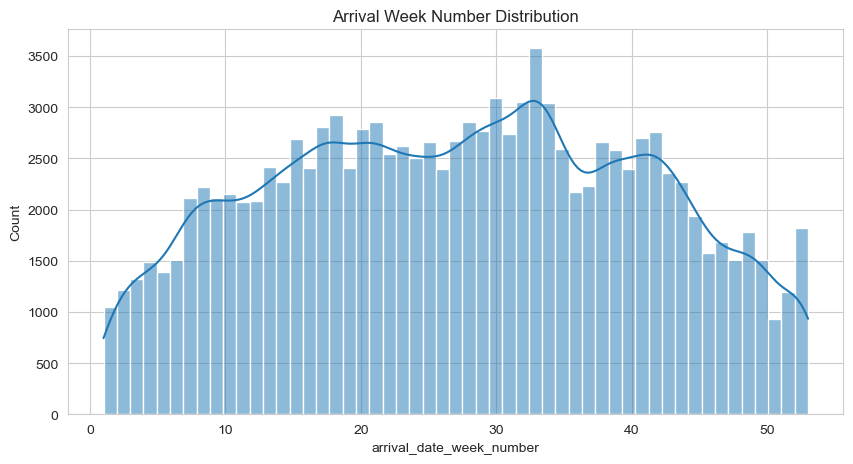

In [65]:
print(hotel['arrival_date_week_number'].describe())
plt.figure(figsize=(10,5))
sns.histplot(hotel['arrival_date_week_number'], bins=53, kde=True)
plt.title('Arrival Week Number Distribution')
plt.show()

### arrival_date_day_of_month

count    119390.000000
mean         15.798241
std           8.780829
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          31.000000
Name: arrival_date_day_of_month, dtype: float64


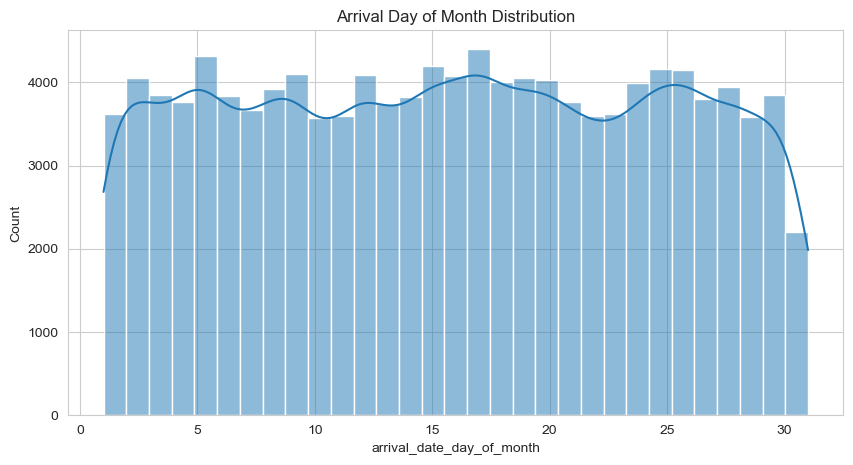

In [66]:
print(hotel['arrival_date_day_of_month'].describe())
plt.figure(figsize=(10,5))
sns.histplot(hotel['arrival_date_day_of_month'], bins=31, kde=True)
plt.title('Arrival Day of Month Distribution')
plt.show()

### stays_in_weekend_nights & stays_in_week_nights

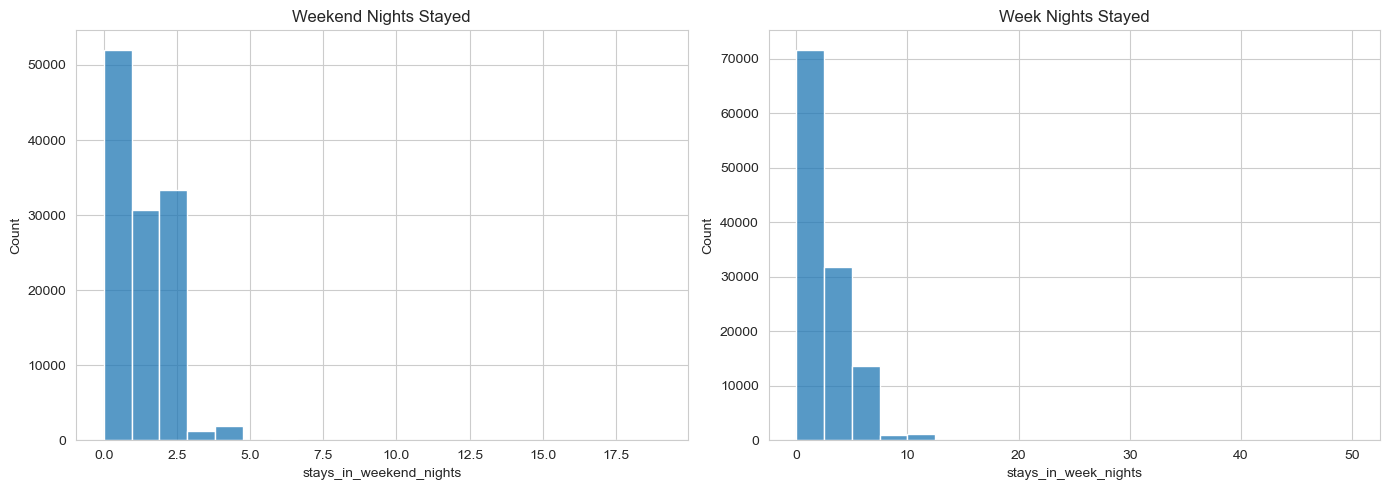

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(hotel['stays_in_weekend_nights'], bins=20, ax=axes[0])
axes[0].set_title('Weekend Nights Stayed')
sns.histplot(hotel['stays_in_week_nights'], bins=20, ax=axes[1])
axes[1].set_title('Week Nights Stayed')
plt.tight_layout()
plt.show()

### adults, children, babies

adults
2     89680
1     23027
3      6202
0       403
4        62
26        5
27        2
20        2
5         2
40        1
50        1
55        1
6         1
10        1
Name: count, dtype: int64

 children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

 babies
0     118473
1        900
2         15
10         1
9          1
Name: count, dtype: int64


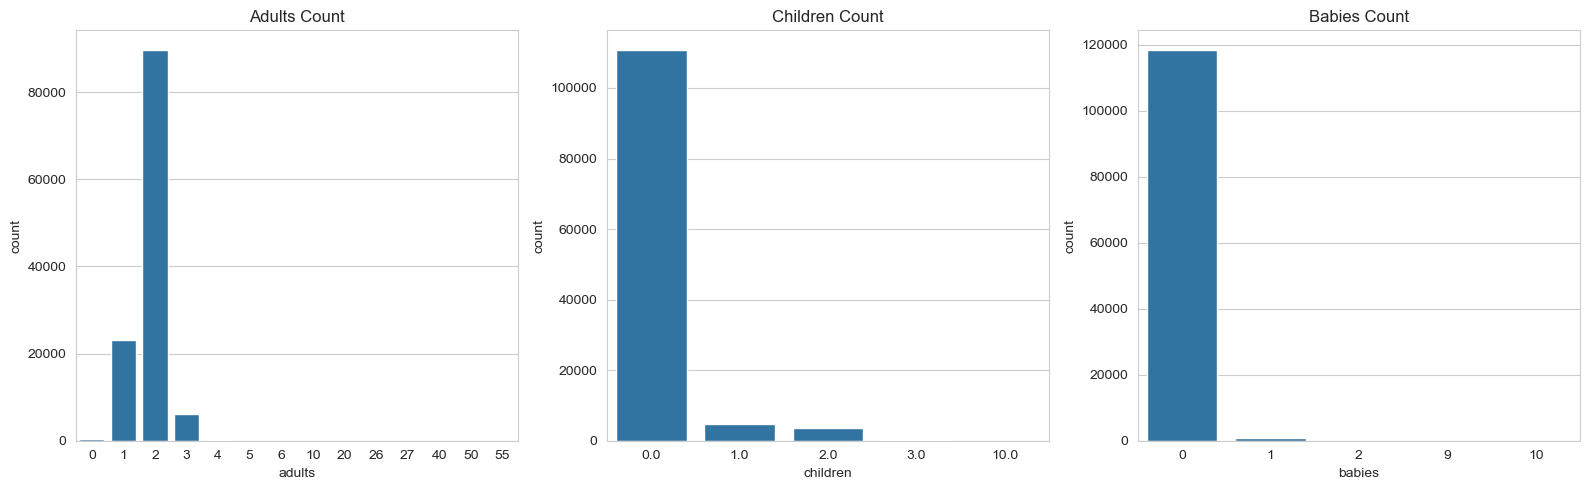

In [68]:
print(hotel['adults'].value_counts())
print('\n', hotel['children'].value_counts())
print('\n', hotel['babies'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.countplot(x='adults', data=hotel, ax=axes[0])
axes[0].set_title('Adults Count')
sns.countplot(x='children', data=hotel, ax=axes[1])
axes[1].set_title('Children Count')
sns.countplot(x='babies', data=hotel, ax=axes[2])
axes[2].set_title('Babies Count')
plt.tight_layout()
plt.show()

### meal

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


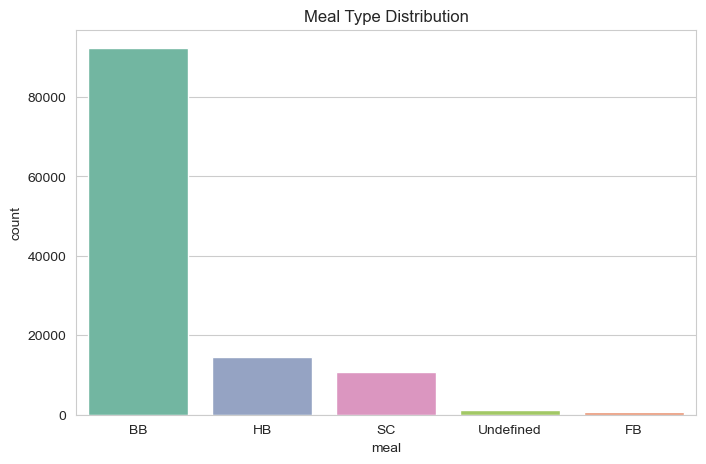

In [69]:
print(hotel['meal'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='meal', data=hotel, hue='meal', palette='Set2', legend=False, order=hotel['meal'].value_counts().index)
plt.title('Meal Type Distribution')
plt.show()

### country

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64


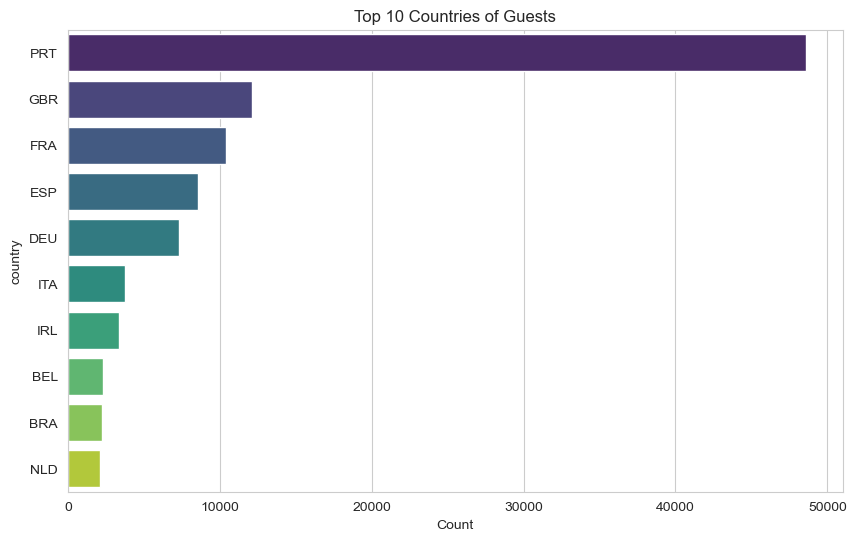

In [70]:
print(hotel['country'].value_counts().head(10))
plt.figure(figsize=(10,6))
top10 = hotel['country'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='viridis', legend=False)
plt.title('Top 10 Countries of Guests')
plt.xlabel('Count')
plt.show()

### market_segment

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


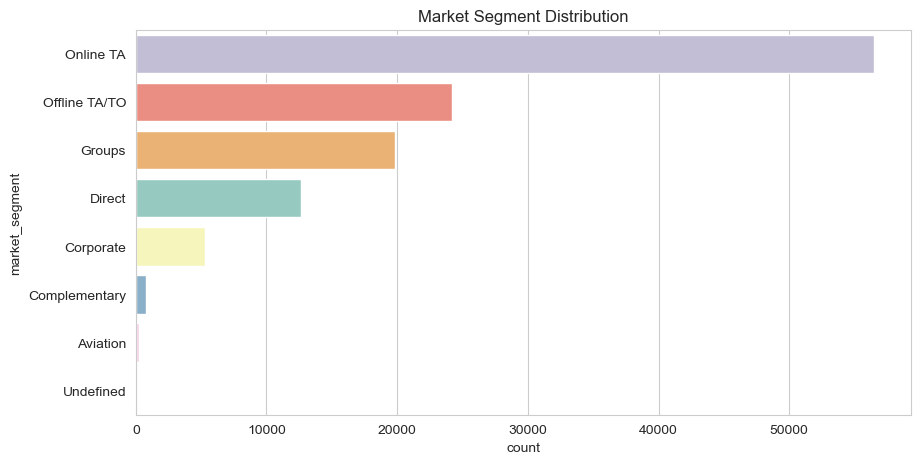

In [71]:
print(hotel['market_segment'].value_counts())
plt.figure(figsize=(10,5))
sns.countplot(y='market_segment', data=hotel, order=hotel['market_segment'].value_counts().index, hue='market_segment', palette='Set3', legend=False)
plt.title('Market Segment Distribution')
plt.show()

### distribution_channel

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64


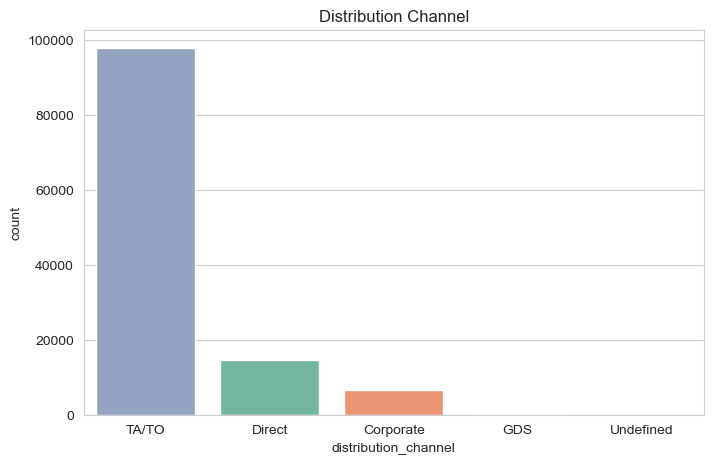

In [72]:
print(hotel['distribution_channel'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='distribution_channel', data=hotel, order=hotel['distribution_channel'].value_counts().index, hue='distribution_channel', palette='Set2', legend=False)
plt.title('Distribution Channel')
plt.show()

### is_repeated_guest

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64


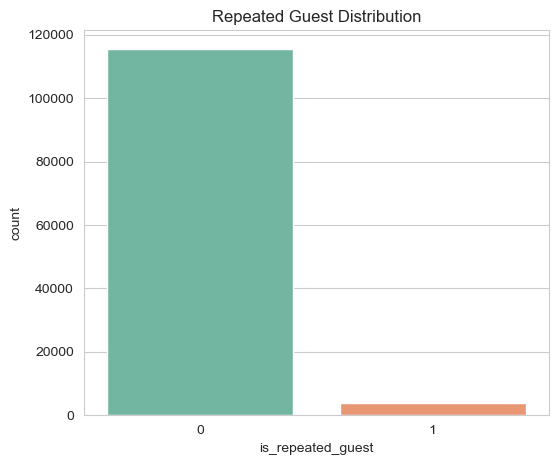

In [73]:
print(hotel['is_repeated_guest'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='is_repeated_guest', data=hotel, hue='is_repeated_guest', palette='Set2', legend=False)
plt.title('Repeated Guest Distribution')
plt.show()

### previous_cancellations & previous_bookings_not_canceled

In [74]:
print(hotel['previous_cancellations'].describe())
print('\n', hotel['previous_bookings_not_canceled'].describe())

count    119390.000000
mean          0.087118
std           0.844336
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.000000
Name: previous_cancellations, dtype: float64

 count    119390.000000
mean          0.137097
std           1.497437
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          72.000000
Name: previous_bookings_not_canceled, dtype: float64


### reserved_room_type & assigned_room_type

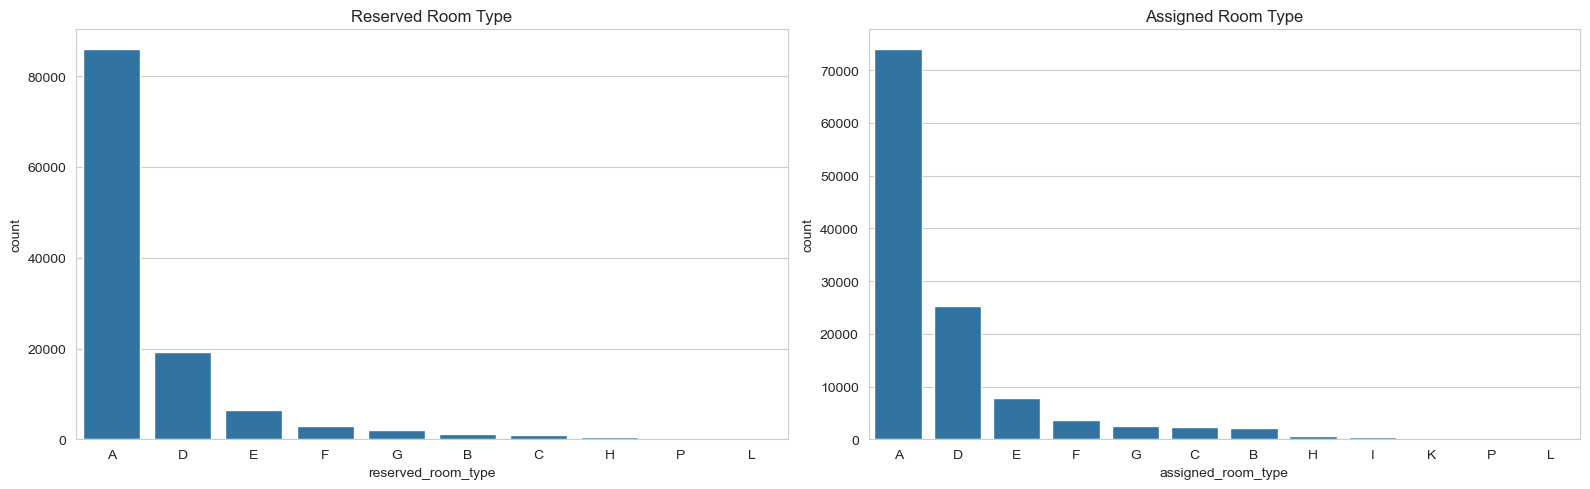

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
sns.countplot(x='reserved_room_type', data=hotel, order=hotel['reserved_room_type'].value_counts().index, ax=axes[0])
axes[0].set_title('Reserved Room Type')
sns.countplot(x='assigned_room_type', data=hotel, order=hotel['assigned_room_type'].value_counts().index, ax=axes[1])
axes[1].set_title('Assigned Room Type')
plt.tight_layout()
plt.show()

### booking_changes

count    119390.000000
mean          0.221124
std           0.652306
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: booking_changes, dtype: float64


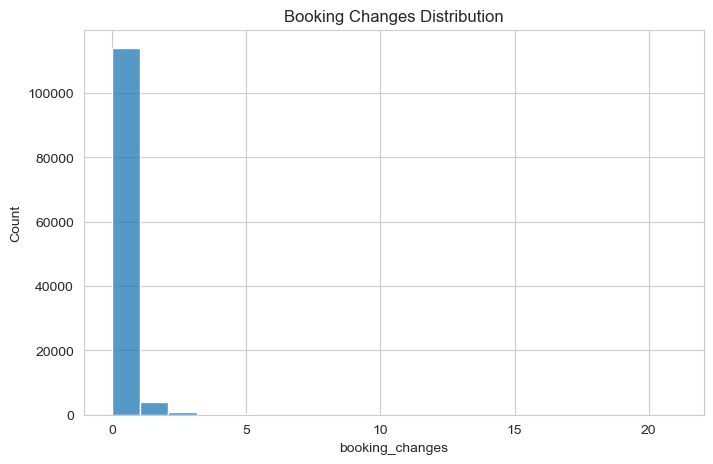

In [76]:
print(hotel['booking_changes'].describe())
plt.figure(figsize=(8,5))
sns.histplot(hotel['booking_changes'], bins=20)
plt.title('Booking Changes Distribution')
plt.show()

### deposit_type

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


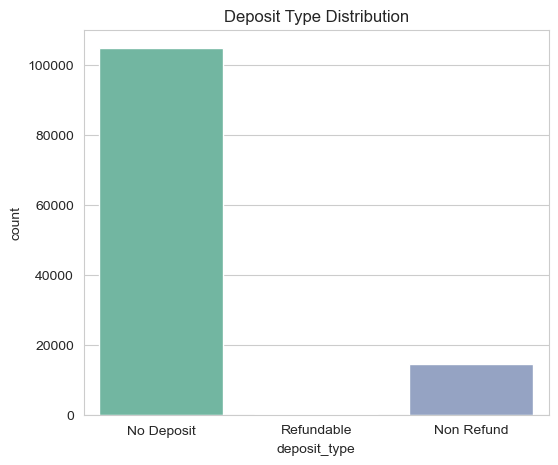

In [77]:
print(hotel['deposit_type'].value_counts())
plt.figure(figsize=(6,5))
sns.countplot(x='deposit_type', data=hotel, hue='deposit_type', palette='Set2', legend=False)
plt.title('Deposit Type Distribution')
plt.show()

### agent & company (high missing - will analyze before cleaning)

In [78]:
print('Agent missing %:', round(hotel['agent'].isnull().sum()/len(hotel)*100, 2))
print('Company missing %:', round(hotel['company'].isnull().sum()/len(hotel)*100, 2))
print('\nTop Agents:')
print(hotel['agent'].value_counts().head(5))

Agent missing %: 13.69
Company missing %: 94.31

Top Agents:
agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
Name: count, dtype: int64


### days_in_waiting_list

count    119390.000000
mean          2.321149
std          17.594721
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         391.000000
Name: days_in_waiting_list, dtype: float64


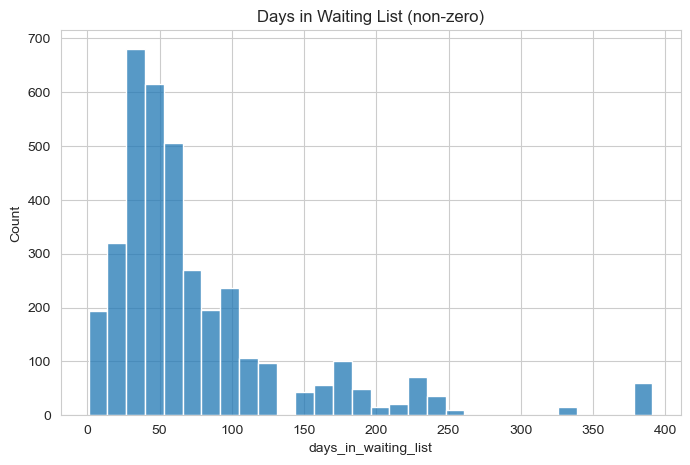

In [79]:
print(hotel['days_in_waiting_list'].describe())
plt.figure(figsize=(8,5))
sns.histplot(hotel[hotel['days_in_waiting_list']>0]['days_in_waiting_list'], bins=30)
plt.title('Days in Waiting List (non-zero)')
plt.show()

### customer_type

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


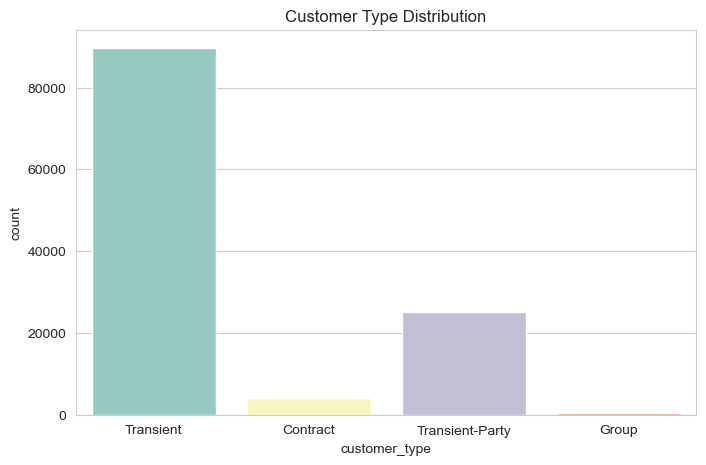

In [80]:
print(hotel['customer_type'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', data=hotel, hue='customer_type', palette='Set3', legend=False)
plt.title('Customer Type Distribution')
plt.show()

### adr (Average Daily Rate)

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


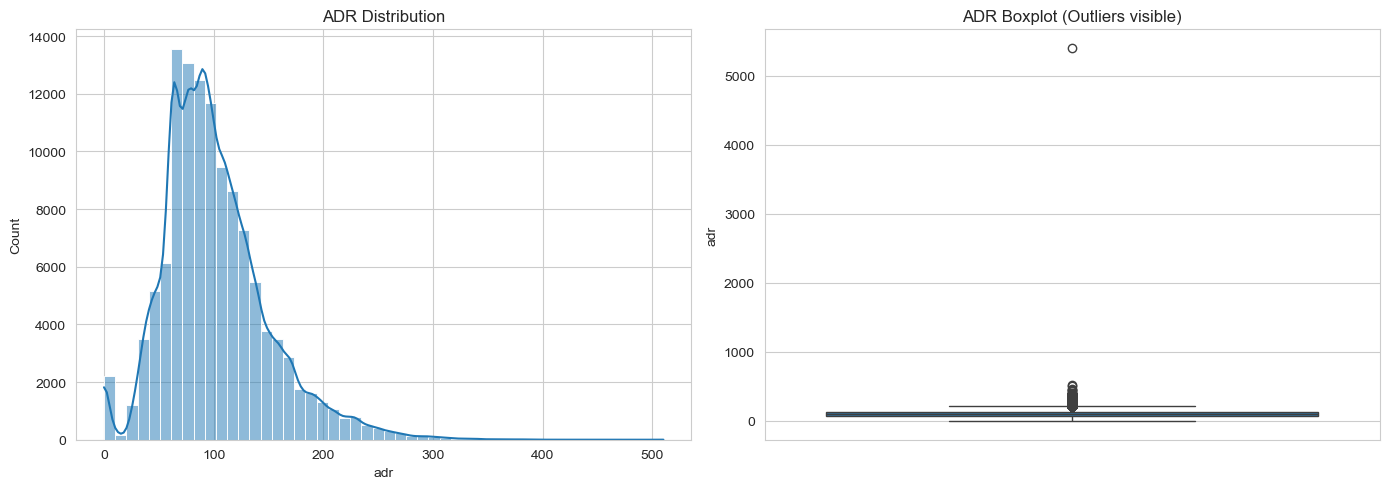

In [81]:
print(hotel['adr'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(hotel[(hotel['adr']>=0) & (hotel['adr']<1000)]['adr'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('ADR Distribution')
sns.boxplot(y=hotel['adr'], ax=axes[1])
axes[1].set_title('ADR Boxplot (Outliers visible)')
plt.tight_layout()
plt.show()

### required_car_parking_spaces & total_of_special_requests

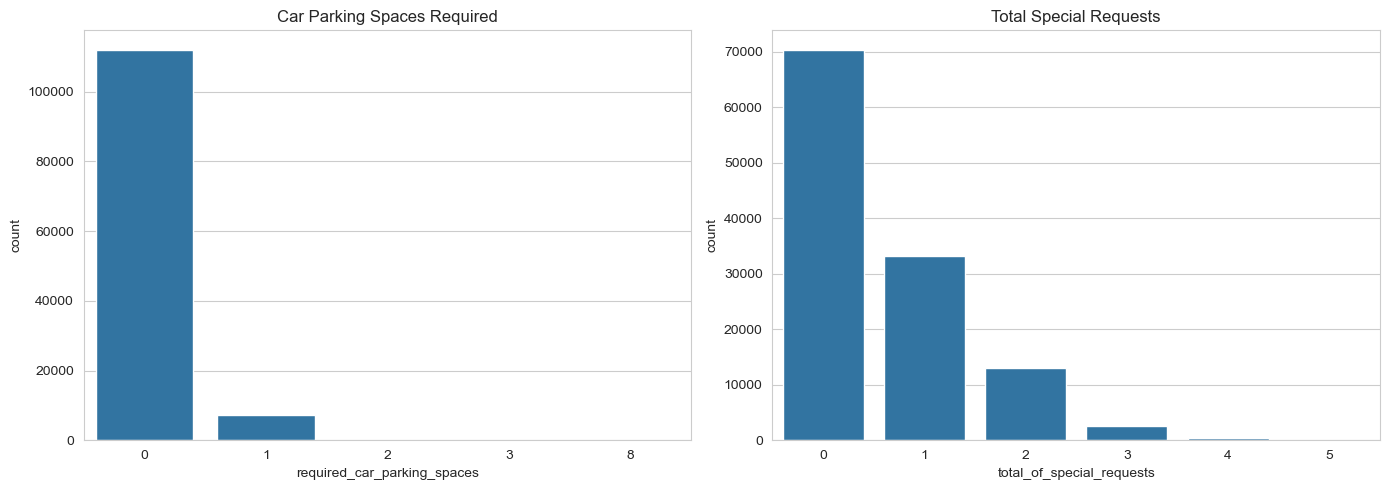

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(x='required_car_parking_spaces', data=hotel, ax=axes[0])
axes[0].set_title('Car Parking Spaces Required')
sns.countplot(x='total_of_special_requests', data=hotel, ax=axes[1])
axes[1].set_title('Total Special Requests')
plt.tight_layout()
plt.show()

### reservation_status & reservation_status_date

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64


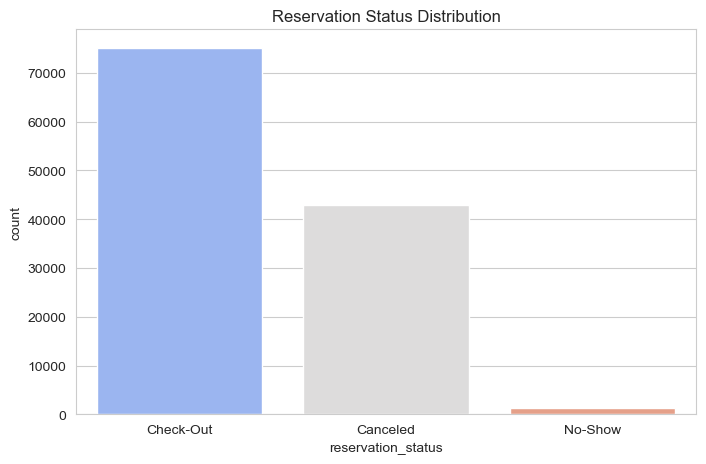

In [83]:
print(hotel['reservation_status'].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(x='reservation_status', data=hotel, hue='reservation_status', palette='coolwarm', legend=False)
plt.title('Reservation Status Distribution')
plt.show()

### name, email, phone-number, credit_card (PII columns)Yeh personally identifiable information (PII) columns hain — privacy ke lihaz se inhe drop kar dena chahiye, statistical analysis ke liye useful nahi hain.

In [84]:
print('Unique names:', hotel['name'].nunique())
print('Unique emails:', hotel['email'].nunique())
print('Sample (first 3 rows hidden for privacy demonstration):')
print(hotel[['name','email','phone-number','credit_card']].head(3))

Unique names: 81503
Unique emails: 115889
Sample (first 3 rows hidden for privacy demonstration):
             name                        email  phone-number       credit_card
0   Ernest Barnes  Ernest.Barnes31@outlook.com  669-792-1661  ************4322
1    Andrea Baker       Andrea_Baker94@aol.com  858-637-6955  ************9157
2  Rebecca Parker   Rebecca_Parker@comcast.net  652-885-2745  ************3734


## 3.4 Bivariate Analysis (Relation with Cancellation)

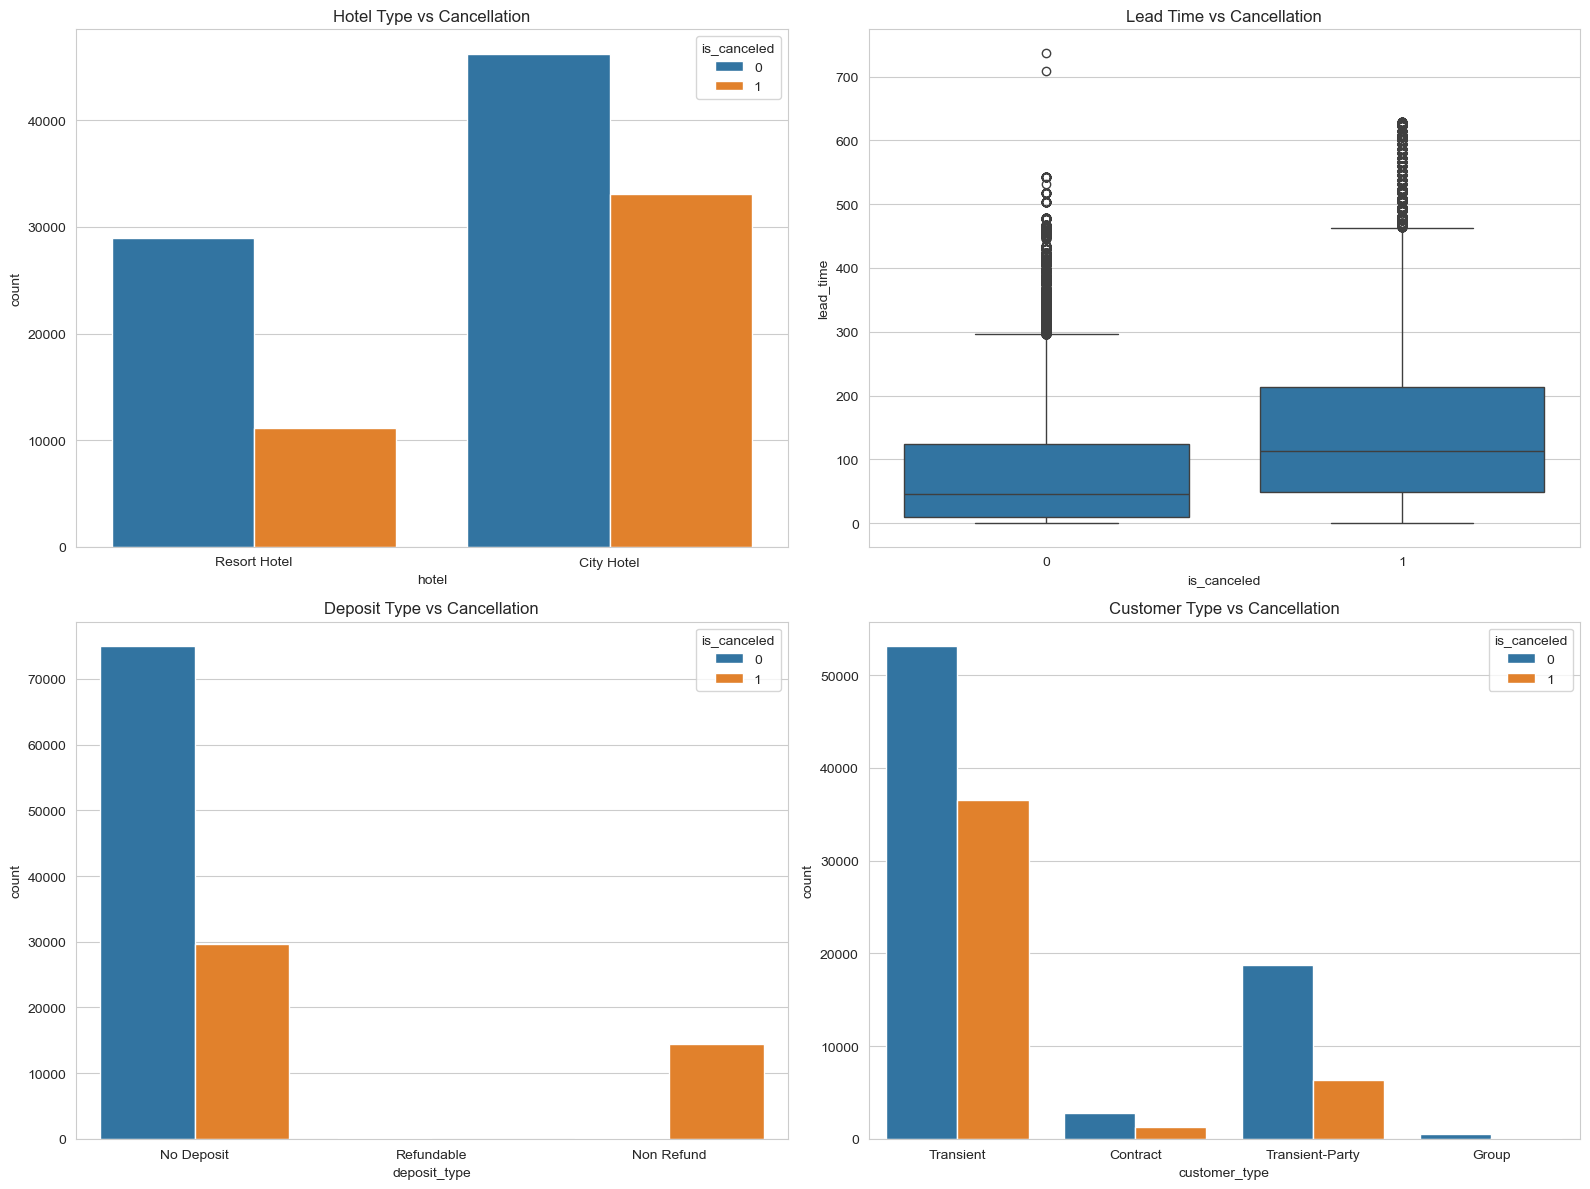

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

sns.countplot(x='hotel', hue='is_canceled', data=hotel, ax=axes[0,0])
axes[0,0].set_title('Hotel Type vs Cancellation')

sns.boxplot(x='is_canceled', y='lead_time', data=hotel, ax=axes[0,1])
axes[0,1].set_title('Lead Time vs Cancellation')

sns.countplot(x='deposit_type', hue='is_canceled', data=hotel, ax=axes[1,0])
axes[1,0].set_title('Deposit Type vs Cancellation')

sns.countplot(x='customer_type', hue='is_canceled', data=hotel, ax=axes[1,1])
axes[1,1].set_title('Customer Type vs Cancellation')

plt.tight_layout()
plt.show()

## 3.5 Correlation Analysis

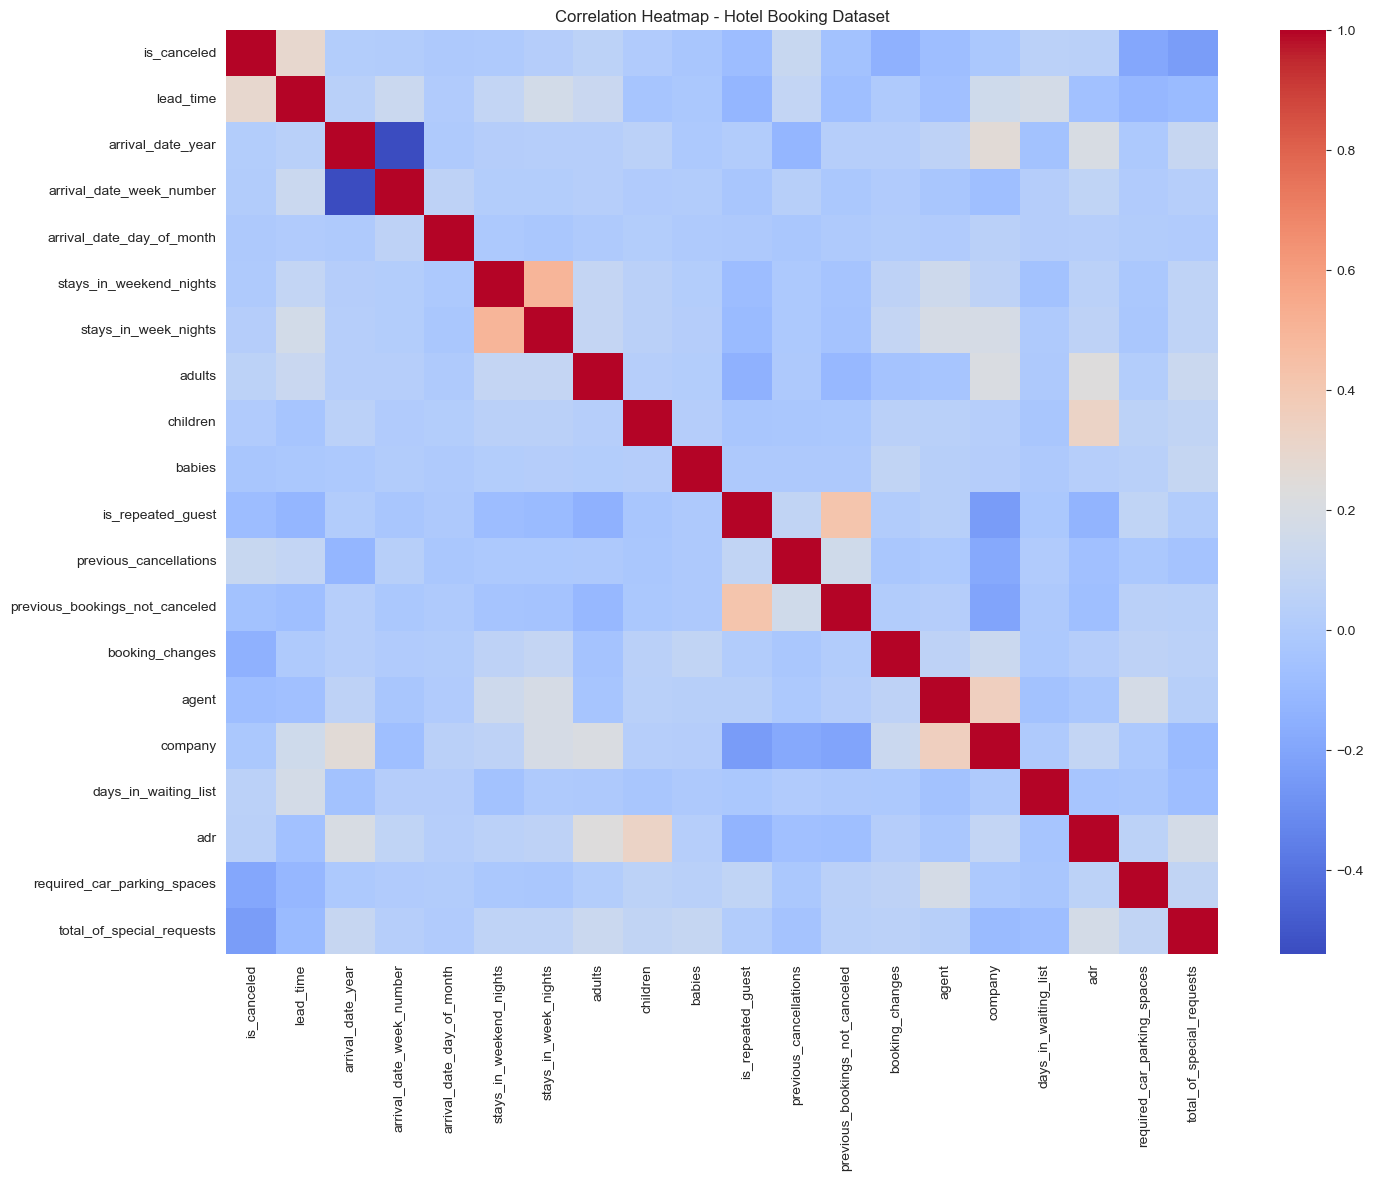

In [86]:
plt.figure(figsize=(16,12))
numeric_hotel = hotel.select_dtypes(include=[np.number])
sns.heatmap(numeric_hotel.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap - Hotel Booking Dataset')
plt.show()

## 3.6 Data Cleaning

In [87]:
hotel_clean = hotel.copy()

# Drop PII columns - not useful and privacy concern
hotel_clean.drop(['name', 'email', 'phone-number', 'credit_card'], axis=1, inplace=True)

# company has 94% missing - drop the column entirely
hotel_clean.drop('company', axis=1, inplace=True)

print('Shape after dropping unnecessary columns:', hotel_clean.shape)

Shape after dropping unnecessary columns: (119390, 31)


In [88]:
# Fill remaining missing values
hotel_clean['children'] = hotel_clean['children'].fillna(0)
hotel_clean['country'] = hotel_clean['country'].fillna(hotel_clean['country'].mode()[0])
hotel_clean['agent'] = hotel_clean['agent'].fillna(0)   # 0 means no agent

print('Missing values after cleaning:')
print(hotel_clean.isnull().sum()[hotel_clean.isnull().sum() > 0])

Missing values after cleaning:
Series([], dtype: int64)


In [89]:
# Remove invalid rows: bookings with 0 adults, 0 children, 0 babies (no guests)
invalid_rows = hotel_clean[(hotel_clean['adults']==0) & (hotel_clean['children']==0) & (hotel_clean['babies']==0)]
print('Invalid rows (no guests):', len(invalid_rows))
hotel_clean = hotel_clean[~((hotel_clean['adults']==0) & (hotel_clean['children']==0) & (hotel_clean['babies']==0))]
print('Shape after removing invalid rows:', hotel_clean.shape)

Invalid rows (no guests): 180
Shape after removing invalid rows: (119210, 31)


In [90]:
# Remove negative or unrealistic ADR values
print('Negative ADR rows:', (hotel_clean['adr'] < 0).sum())
hotel_clean = hotel_clean[hotel_clean['adr'] >= 0]

# Remove extreme ADR outlier (5400+ is unrealistic)
hotel_clean = hotel_clean[hotel_clean['adr'] < 1000]
print('Shape after cleaning ADR:', hotel_clean.shape)

Negative ADR rows: 1
Shape after cleaning ADR: (119208, 31)


In [91]:
# Remove duplicate rows
print('Duplicates before:', hotel_clean.duplicated().sum())
hotel_clean.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', hotel_clean.shape)

Duplicates before: 32006
Shape after removing duplicates: (87202, 31)


In [92]:
# Convert reservation_status_date to datetime
hotel_clean['reservation_status_date'] = pd.to_datetime(hotel_clean['reservation_status_date'])
print(hotel_clean['reservation_status_date'].dtype)

datetime64[ns]


In [93]:
# Save cleaned hotel dataset
hotel_clean.to_csv('cleaned_hotel_booking.csv', index=False)
hotel_clean.head()
print('Cleaned Hotel Booking dataset saved as cleaned_hotel_booking.csv')

Cleaned Hotel Booking dataset saved as cleaned_hotel_booking.csv


### Final Summary
**Dataset 1 - Loan:** Missing values categorical mode aur numeric median se fill kiye gaye, ApplicantIncome aur LoanAmount mein outliers IQR method se remove kiye gaye, Dependents column standardize kiya gaya, Loan_ID drop kiya gaya.

**Dataset 2 - Adult:** '?' placeholder values ko NaN mein convert karke mode se fill kiya gaya, duplicate rows remove kiye gaye, age column mein outliers IQR method se handle kiye gaye.

**Dataset 3 - Hotel Booking:** PII columns (name, email, phone, credit_card) aur high-missing company column drop kiye gaye, children/country/agent missing values fill kiye gaye, invalid bookings (zero guests) aur unrealistic ADR values remove kiye gaye, duplicates clean kiye gaye, date column proper datetime format mein convert kiya gaya.

Teeno cleaned datasets save ho chuke hain:- `cleaned_loan.csv`- `cleaned_adult.csv`- `cleaned_hotel_booking.csv`